# Upload train, dev, test .cupt files

In [ ]:
from google.colab import files

# Upload multiple .cupt files
uploaded = files.upload()


Saving train.cupt to train.cupt


In [ ]:
print("Uploaded files:")
for fname in uploaded:
    print("-", fname)


Uploaded files:
- train.cupt


# Preview the first 30 lines of the train.cupt file

In [ ]:
file_path = 'train.cupt'

sentence_count = 0
print("First 30 lines of train.cupt:\n" + "-"*40)
with open(file_path, encoding='utf-8') as f:
    for i in range(30):
        line = f.readline()
        if not line:
            break
        print(line.strip())

First 30 lines of train.cupt:
----------------------------------------
# global.columns = ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC PARSEME:MWE
# source_sent_id = . . HaAretz-2214
# text = מוטב שהם לא יטיפו מוסר לאחרים
1	מוטב	מוטב	NOUN	NOUN	Gender=Masc|Number=Sing	4	nsubj	_	_	*
2	שהם	שהם	PRON	PRON	_	1	nmod:poss	_	_	*
3	לא	לא	ADV	ADV	_	4	advmod	_	_	*
4	יטיפו	הטיף	VERB	VERB	Gender=Masc|HebBinyan=HIFIL|Number=Plur|Person=3|Tense=Fut|Voice=Act	0	root	_	_	1:LVC.full
5	מוסר	מוסר	NOUN	NOUN	Gender=Masc|Number=Sing	4	obj	_	_	1
6	לאחרים	לאחר	ADJ	ADJ	Gender=Masc|Number=Plur	5	amod	_	_	*

# source_sent_id = . . Arutz7-717
# text = אנו מאמנים בני 17 ו 18 לתקוף מתנחלים ולחטוף חיילים בתוך שטחי ישראל
1	אנו	הוא	PRON	PRON	Gender=Fem,Masc|Number=Plur|Person=1|PronType=Prs	2	nsubj	_	_	*
2	מאמנים	מאמן	NOUN	NOUN	Gender=Masc|Number=Plur	0	root	_	_	*
3	בני	בן	NOUN	NOUN	Definite=Cons|Gender=Masc|Number=Plur	2	xcomp	_	_	*
4	17	17	NUM	NUM	_	3	compound	_	_	*
5	ו	ו	CCONJ	CCONJ	_	6	cc	_	_	*
6	18	18	NUM	NU

## Column Descriptions for `.cupt` Files

Each line in a `.cupt` file represents one token (word) in a sentence.
Sentences are separated by empty lines.

| Column Index | Example   | Description |
|--------------|-----------|-------------|
| **0**        | `1`       | Token ID – the position of the token in the sentence |
| **1**        | `קנה`     | FORM – the actual surface word (as it appears in text) |
| **2**        | `לקנות`   | LEMMA – the base or dictionary form of the word |
| **3**        | `VERB`    | UPOS – universal part of speech (e.g., NOUN, VERB) |
| **4**        | `VB`      | XPOS – language-specific part of speech (for Hebrew) |
| **5**        | `_`       | FEATS – morphological features (gender, number, tense...) |
| **6**        | `0`       | HEAD – the ID of the syntactic head (dependency tree) |
| **7**        | `root`    | DEPREL – syntactic relation to the HEAD (e.g., subject, object) |
| **8**        | `_`       | DEPS – additional syntactic dependencies (optional) |
| **9**        | `_`       | MISC – miscellaneous info (e.g., SpaceAfter=No) |
| **10**       | `VID_1` / `*` | PARSEME:MWE – whether the token is part of a multiword expression (MWE), and its type/ID |

🟡 If the last column is `*`, the token is **not** part of an MWE.  
🟢 If it is `VID_1`, `LVC_2`, etc., it indicates MWE type and group number within the sentence.

# Total number of sentence instances

In [ ]:

sentence_count = 0
with open(file_path, encoding='utf-8') as f:
    for line in f:
        if line.strip() == "":
            sentence_count += 1

print(f" Total number of sentence instances: {sentence_count}")


 Total number of sentence instances: 14035


# Step 1.1: Extract MWEs from a .cupt file


In [ ]:
def extract_mwes_from_cupt(file_path):
    sentences_with_mwes = []
    current_sentence = []
    current_mwes = {}

    with open(file_path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if line == "":
                if current_mwes:
                    sentences_with_mwes.append({
                        "tokens": current_sentence.copy(),
                        "mwes": current_mwes.copy()
                    })
                current_sentence = []
                current_mwes = {}
                continue

            if line.startswith("#"):
                continue

            parts = line.split('\t')
            if len(parts) < 11:
                continue

            token = parts[1]
            mwe_info = parts[10]

            current_sentence.append(token)

            if mwe_info != '*':
                for mwe_tag in mwe_info.split(';'):
                    if '_' in mwe_tag:
                        mwe_type, mwe_id = mwe_tag.split('_')
                        mwe_key = f"{mwe_type}_{mwe_id}"
                    else:
                        mwe_type = mwe_tag
                        mwe_key = f"{mwe_type}_default"

                    if mwe_key not in current_mwes:
                        current_mwes[mwe_key] = {
                            "type": mwe_type,
                            "indices": [],
                            "words": []
                        }

                    current_mwes[mwe_key]["indices"].append(len(current_sentence)-1)
                    current_mwes[mwe_key]["words"].append(token)

    return sentences_with_mwes


file_path = 'train.cupt'
mwe_data = extract_mwes_from_cupt(file_path)

# Show first 3 examples
for i, item in enumerate(mwe_data[:3]):
    print(f"\nSentence {i+1}: {' '.join(item['tokens'])}")
    for mwe_key, mwe_info in item["mwes"].items():
      if ':' in mwe_key:
        print(mwe_key)
      print(f"  MWE [{mwe_key}] → {' '.join(mwe_info['words'])} | indices = {mwe_info['indices']}")



Sentence 1: מוטב שהם לא יטיפו מוסר לאחרים
1:LVC.full_default
  MWE [1:LVC.full_default] → יטיפו | indices = [3]
  MWE [1_default] → מוסר | indices = [4]

Sentence 2: הדולר ה דולר ממשיך לקבוע את מגמת המסחר ה מסחר היומית ה יומית בשוק ב שוק הסולידי ה סולידי , דרך השפעתו השפעה_ _של_ _הוא התיאורטית ה תיאורטית על מאפייני התמחור של האפיקים השונים ה שונים
1:LVC.full_default
  MWE [1:LVC.full_default] → ממשיך | indices = [3]
  MWE [1_default] → לקבוע | indices = [4]

Sentence 3: כל אשר עוד עולה בדעתכם הוא לערוך מערכת של בריתות בלתי - אפשריות , חסרות כל בסיס הגיוני , לא כדי להבטיח גבולות לארץ - ישראל , ולא כדי להביא שלום על ישראל , אלא כדי להאריך את ימיכם על כיסאותיכם
1:VID_default
  MWE [1:VID_default] → עולה | indices = [3]
  MWE [1_default] → בדעתכם | indices = [4]


# 1.2 Extract 20 MWE examples from the corpus


In [ ]:
list(item["mwes"].items())[0]

('1:VID_default', {'type': '1:VID', 'indices': [3], 'words': ['עולה']})

In [ ]:
import pandas as pd

def extract_mwe_examples_to_dataframe(mwe_data, max_examples=20):
    examples = []

    for item in mwe_data:
        if not item["mwes"]:
            continue

        for mwe_key, mwe_info in list(item["mwes"].items()):
            if ':' in mwe_key:
                mwe_t = mwe_key.split(':')[1].split('_')[0]
            if len(mwe_info["words"]) >= 2:
                example = {
                    "full_sentence": ' '.join(item["tokens"]),
                    "mwe_expression": ' '.join(mwe_info["words"]),
                    "mwe_type": mwe_t,
                    "mwe_key":mwe_key
                }
                examples.append(example)
                break

        if len(examples) >= max_examples:
            break

    df = pd.DataFrame(examples)
    return df

In [ ]:
pd.set_option('display.max_colwidth', None)
extract_mwe_examples_to_dataframe(mwe_data)


,full_sentence,mwe_expression,mwe_type,mwe_key
0,"לדבריהם , שיווק הסולר הוריד משמעותית את היקף המכירות שלהם , ומתן האפשרות לשיווק בנזין רק יחמיר את המצב",את המצב,LVC.full,1_default
1,"יו "" ר הוועדה ח "" כ אמנון כהן הודיע כי הועדה בראשותו תהיה עם יד על הדופק בעניין יישום מסקנות ועדת הבדיקה שמינה משרד התחבורה בנושא",עם יד על הדופק,VID,1_default
2,כיום ניתן להציג את השאלה שהציג האיש בפני הנער המחפש אחר גן העדן גם לפני הצעירים המפוצצים את עצמם ומפוצצים מכוניות תופת כשהם בתוכן כדי להגיע לגן עדן שכן הם ללא ספק מושפעים מחוות הדעת ההלכתיות הרעיונות הנטיות וההוראות של האנשים שרכשו את אמונם של הצעירים והשפיעו עליהם רבות,את אמונם,VPC.full,1_default
3,"אני מודיע לך איילה אלה בתי הייתה חוליה בתוך שרשרת ההתחברות ואני מתפלל לקב "" ה ולהחלמתה והיא תעמוד כנגד אותה התנתקות שאתה מתכנן",חוליה בתוך שרשרת,VID,1_default
4,הארגון לבטחון ושיתוף פעולה יפרסם את החלטתו בדבר הבחירות ביום שני אולם כבר נרמז כי לדעת בכיריו ההצבעה המוקדמת היא דלת פתוחה להונאה בחירות,דלת פתוחה,VID,1_default
5,"בתגובה אמר ח "" כ בני אלון ליומן סוגרים יום של ערוץ 7 כי לא לגיטימי לגרש יהודים על בסיס חודו של קול ערבי",חודו של קול,VID,1_default
6,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",בסימן שאלה,VID,1_default
7,בראיון ל הארץ אישר שרון שהבטיח לאבו מאזן לשחרר אסירים עם דם על הידיים,דם על הידיים,VID,1_default
8,ראש הממשלה אריאל שרון תוקף הבוקר את דבריו של חבר הכנסת עוזי לנדאו לפיהם הוא עלול לחלק את ירושלים וקובע ירושלים היא בירת ישראל לנצח נצחים,את דבריו,VPC.full,1_default
9,"מנהלי מטאלינק משוכנעים כי השיפור ה שיפור נמצא "" מעבר לפינה "" ( כדברי כ דברי עופר לביא , סמנכ""ל הכספים ה כספים ) וכי ו כי החברה ה חברה הישראלית ה ישראלית תהפוך לשחקנית דומיננטית בשוק ב שוק ה - ( וידיאו על גבי )",מעבר לפינה,VID,1_default


#1.3 Count how many times each MWE expression appears in the dataset

In [ ]:
import pandas as pd

def extract_mwe_examples_to_dataframe(mwe_data):

    examples = []

    for item in mwe_data:
        if not item["mwes"]:
            continue

        for mwe_key, mwe_info in item["mwes"].items():
            if ':' in mwe_key:
                mwe_t = mwe_key.split(':')[1].split('_')[0]
            if "words" in mwe_info and len(mwe_info["words"]) >= 2:
                example = {
                    "full_sentence": ' '.join(item["tokens"]),
                    "mwe_expression": ' '.join(mwe_info["words"]),
                    "mwe_type": mwe_t
                }
                examples.append(example)
                break

    df = pd.DataFrame(examples)
    return df

def count_mwe_frequencies(df):

    counts = df['mwe_expression'].value_counts()

    print(f"\nTotal number of sentences with MWEs: {len(df)}\n")

    for expression, count in counts.items():
        print(f"'{expression}' appears in {count} sentence(s)")


df_mwe = extract_mwe_examples_to_dataframe(mwe_data)
count_mwe_frequencies(df_mwe)


Total number of sentences with MWEs: 509

'על הדעת' appears in 11 sentence(s)
'לידי ביטוי' appears in 11 sentence(s)
'דם על הידיים' appears in 11 sentence(s)
'את הדין' appears in 6 sentence(s)
'את מותם' appears in 6 sentence(s)
'את הנפש' appears in 6 sentence(s)
'את הקרקע' appears in 5 sentence(s)
'על שולחן' appears in 5 sentence(s)
'את דבריו' appears in 4 sentence(s)
'על חשבון' appears in 4 sentence(s)
'היה ולא נברא' appears in 3 sentence(s)
'על חייה' appears in 3 sentence(s)
'את חייו' appears in 3 sentence(s)
'על דעתו' appears in 3 sentence(s)
'את רוחם' appears in 3 sentence(s)
'היתה ולא נבראה' appears in 3 sentence(s)
'את המערכה' appears in 3 sentence(s)
'את ידי' appears in 3 sentence(s)
'חודו של קול' appears in 3 sentence(s)
'את האות' appears in 3 sentence(s)
'את דתו' appears in 3 sentence(s)
'על סף' appears in 3 sentence(s)
'בקנה אחד' appears in 3 sentence(s)
'ידיים ורגליים' appears in 3 sentence(s)
'את עצמם' appears in 3 sentence(s)
'את חומותיו' appears in 2 sentence(s)
'את מותו

In [ ]:
df_mwe

,full_sentence,mwe_expression,mwe_type
0,"לדבריהם , שיווק הסולר הוריד משמעותית את היקף המכירות שלהם , ומתן האפשרות לשיווק בנזין רק יחמיר את המצב",את המצב,LVC.full
1,"יו "" ר הוועדה ח "" כ אמנון כהן הודיע כי הועדה בראשותו תהיה עם יד על הדופק בעניין יישום מסקנות ועדת הבדיקה שמינה משרד התחבורה בנושא",עם יד על הדופק,VID
2,כיום ניתן להציג את השאלה שהציג האיש בפני הנער המחפש אחר גן העדן גם לפני הצעירים המפוצצים את עצמם ומפוצצים מכוניות תופת כשהם בתוכן כדי להגיע לגן עדן שכן הם ללא ספק מושפעים מחוות הדעת ההלכתיות הרעיונות הנטיות וההוראות של האנשים שרכשו את אמונם של הצעירים והשפיעו עליהם רבות,את אמונם,VPC.full
3,"אני מודיע לך איילה אלה בתי הייתה חוליה בתוך שרשרת ההתחברות ואני מתפלל לקב "" ה ולהחלמתה והיא תעמוד כנגד אותה התנתקות שאתה מתכנן",חוליה בתוך שרשרת,VID
4,הארגון לבטחון ושיתוף פעולה יפרסם את החלטתו בדבר הבחירות ביום שני אולם כבר נרמז כי לדעת בכיריו ההצבעה המוקדמת היא דלת פתוחה להונאה בחירות,דלת פתוחה,VID
...,...,...,...
504,"בפתיחתו היה לומד על ייחודה הדמוקרטי של ההסתדרות , כתנועה מקצועית המקיימת בחירות , מצווה "" שדומה שאין לה אח ורע בתנועות המקצועיות בעולם , במזרח ובמערב כאחד """,לה אח ורע,VID
505,"בתור אחד שדיבר ש דיבר על מכירות של 100 מיליון דולר בשנה ב ה_ שנה ולא ו לא הצליח להגיע אליהן אל_ _הן מעולם ( אם כי התקרב ) , ומאוחר ו מאוחר יותר קיווה גם להכנסות ל ה_ הכנסות של מיליארד דולר עד 2005 ונכווה ברותחים , הוא נזהר היום בצוננים , ואינו ו אינו מוכן להתחייב",ברותחים נזהר בצוננים,VID
506,"דובר עובדי מד "" א חגי אמר כי בשנה האחרונה העובדים כורעים תחת נטל העבודה ומשועבדים שמכריז על אירועים יום יומיים בהם נדרשת עזרתם",תחת נטל,VID
507,"ראש אכ "" א , האלוף רן גורן , הסתבך : הוא אמר לעיתון "" במחנה "" דברים שעוררו את רוגזו של הרמטכ "" ל והיה עליו לחזור בו מדבריו",את רוגזו,LVC.cause


# Print the 50 most frequent MWEs that do NOT start with "את"

In [ ]:
def print_top_mwes_excluding_et(df, top_n=50):

    filtered_df = df[~df['mwe_expression'].str.startswith("את")]

    counts = filtered_df['mwe_expression'].value_counts()

    print(f"\n Top {top_n} most frequent MWEs (excluding 'את'):\n")
    for expression, count in counts.head(top_n).items():
        print(f"{expression} appears in {count} sentence(s)")

print_top_mwes_excluding_et(df_mwe)



 Top 50 most frequent MWEs (excluding 'את'):

לידי ביטוי appears in 11 sentence(s)
על הדעת appears in 11 sentence(s)
דם על הידיים appears in 11 sentence(s)
על שולחן appears in 5 sentence(s)
על חשבון appears in 4 sentence(s)
על חייה appears in 3 sentence(s)
חודו של קול appears in 3 sentence(s)
על סף appears in 3 sentence(s)
היה ולא נברא appears in 3 sentence(s)
ידיים ורגליים appears in 3 sentence(s)
בקנה אחד appears in 3 sentence(s)
על דעתו appears in 3 sentence(s)
היתה ולא נבראה appears in 3 sentence(s)
על נס appears in 2 sentence(s)
על כרעי תרנגולת appears in 2 sentence(s)
בסימן שאלה appears in 2 sentence(s)
עם המשחקים appears in 2 sentence(s)
שיקול דעת appears in 2 sentence(s)
מן הכוח אל הפועל appears in 2 sentence(s)
עין בעין appears in 2 sentence(s)
אל הפועל appears in 2 sentence(s)
הנער הזה התפללנו appears in 2 sentence(s)
גובה הלהבות appears in 2 sentence(s)
על שתיקה appears in 2 sentence(s)
שייצא עשן לבן appears in 2 sentence(s)
לשון הרע appears in 2 sentence(s)
הארוכה תשיג app

# Print the top-N MWEs (not starting with "את") and one example sentence for each

In [ ]:
def get_top_mwes_with_examples(df, top_n=50):

    filtered_df = df[~df['mwe_expression'].str.startswith("את")]

    counts = filtered_df['mwe_expression'].value_counts().head(top_n)

    data = []
    for expression, count in counts.items():
        example_row = filtered_df[filtered_df['mwe_expression'] == expression].iloc[0]
        data.append({
            'mwe_expression': expression,
            'frequency': count,
            'idiomatic_example_sentence': example_row['full_sentence'],
            'manual_literal_sentence': ''
        })

    return pd.DataFrame(data)

In [ ]:
def print_top_mwes_with_examples(df, top_n=50):

    filtered_df = df[~df['mwe_expression'].str.startswith("את")]

    counts = filtered_df['mwe_expression'].value_counts()

    print(f"\n Top {top_n} MWEs with example sentences (excluding 'את'):\n")

    for expression, count in counts.head(top_n).items():
        example_sentence = filtered_df[filtered_df['mwe_expression'] == expression].iloc[0]['full_sentence']
        print(f" --{expression} → {count} sentence(s)")
        print(f"   Example: {example_sentence}\n")

print_top_mwes_with_examples(df_mwe)



 Top 50 MWEs with example sentences (excluding 'את'):

 --לידי ביטוי → 11 sentence(s)
   Example: באקדמיה כ051 סטודנטים לתואר שני בתשעה תחומים שונים , מאדריכלות ועד הדפס , צילום , מתכות , קרמיקה , שרב - גוניותם אינה באה לידי ביטוי בתערוכה

 --על הדעת → 11 sentence(s)
   Example: דרך אגב , הד לאותה גישה מוצאים בעיתון " הארץ " , המעניק עדיין את התואר " סופר הארץ " לכותביו , אף - על - פי שלא יעלה על הדעת לכנותם סופרים

 --דם על הידיים → 11 sentence(s)
   Example: בראיון ל הארץ אישר שרון שהבטיח לאבו מאזן לשחרר אסירים עם דם על הידיים

 --על שולחן → 5 sentence(s)
   Example: לא יקרא אדם להטלת חרם על איש ציבור או אדם פרטי לא יקח אדם חלק בביצוע חרם שהוטל על ידי כל גורם שהוא כך קובעת הצעת חוק שהונחה על שולחן הכנסת ועיקרה מאבק בחרמות

 --על חשבון → 4 sentence(s)
   Example: הממונה על התקציבים באוצר קובי הבר אומר כי מימון הסכמים קואליציוניים נוספים יבוא על חשבון קיצוצים בנושאים חברתיים ובטחון

 --על חייה → 3 sentence(s)
   Example: קברנו 2 תושבים מפיגוע בקרני ביום שישי יש לנו נערה צעירה שנאבקת ע

Create Masked MWE Sentences for Top-N Frequent Expressions (not starting with "את")

In [ ]:
import random
import pandas as pd

def create_top_masked_mwe_sentences(mwe_data_df, top_n=50):

    filtered_df = mwe_data_df[
        mwe_data_df['mwe_expression'].apply(lambda x: len(x.split()) >= 2) &
        ~mwe_data_df['mwe_expression'].str.startswith("את")
    ].copy()

    top_mwes = filtered_df['mwe_expression'].value_counts().head(top_n).index.tolist()

    top_mwe_df = filtered_df[filtered_df['mwe_expression'].isin(top_mwes)].copy()
    top_mwe_df = top_mwe_df.sample(frac=1, random_state=42)

    seen_mwes = set()
    masked_examples = []

    for index, row in top_mwe_df.iterrows():
        mwe_expression = row['mwe_expression']
        if mwe_expression in seen_mwes:
            continue

        full_sentence = row['full_sentence']
        mwe_type = row['mwe_type']

        sentence_tokens = full_sentence.split()
        mwe_tokens = mwe_expression.split()

        if not mwe_tokens:
            continue

        start_index = -1
        full_sentence_normalized = ' '.join(sentence_tokens)
        mwe_expression_normalized = ' '.join(mwe_tokens)

        try:
            char_start_index = full_sentence_normalized.find(mwe_expression_normalized)
            if char_start_index == -1:
                for i in range(len(sentence_tokens) - len(mwe_tokens) + 1):
                    if ' '.join(sentence_tokens[i:i+len(mwe_tokens)]) == mwe_expression:
                        start_index = i
                        break
            else:
                pre_mwe_text = full_sentence_normalized[:char_start_index].strip()
                start_index = len(pre_mwe_text.split()) if pre_mwe_text else 0

            if start_index == -1 or start_index + len(mwe_tokens) > len(sentence_tokens):
                continue

        except Exception:
            continue

        masked_sentence_tokens = list(sentence_tokens)
        masked_word_index = start_index + len(mwe_tokens) - 1

        if 0 <= masked_word_index < len(masked_sentence_tokens):
            original_masked_word = masked_sentence_tokens[masked_word_index]
            masked_sentence_tokens[masked_word_index] = '[MASK]'
            masked_sentence = ' '.join(masked_sentence_tokens)

            masked_examples.append({
                'original_sentence': full_sentence,
                'masked_sentence': masked_sentence,
                'original_mwe': mwe_expression,
                'masked_word': original_masked_word,
                'is_mwe': True,
                'type': mwe_type,
            })

            seen_mwes.add(mwe_expression)

        if len(seen_mwes) >= top_n:
            break

    return pd.DataFrame(masked_examples)


df_mwe_full = extract_mwe_examples_to_dataframe(mwe_data)

df_mwe_filtered = df_mwe_full[df_mwe_full['mwe_expression'].apply(lambda x: len(x.split()) >= 2)].copy()

masked_mwe_sentences = create_top_masked_mwe_sentences(df_mwe_filtered)

print("\n--- Masked MWE Sentences (First 10) ---")
for i, row in masked_mwe_sentences.head(10).iterrows():
    print(f"Original: {row['original_sentence']}")
    print(f"Masked:   {row['masked_sentence']}")
    print(f"MWE:      {row['original_mwe']}")
    print(f"Masked Word: {row['masked_word']}")
    print(f"type: {row['type']}\n")

print(f"Total masked MWE examples created: {len(masked_mwe_sentences)}")


--- Masked MWE Sentences (First 10) ---
Original: לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו
Masked:   לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו
MWE:      היתה ולא נבראה
Masked Word: נבראה
type: VID

Original: יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות
Masked:   יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות
MWE:      על חייה
Masked Word: חייה
type: VID

Original: מאז הקמתה , נשענה הממשלה על כרעי תרנגולת
Masked:   מאז הקמתה , נשענה הממשלה על כרעי [MASK]
MWE:      על כרעי תרנגולת
Masked Word: תרנגולת
type: VID

Original: הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה
Masked:   הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה
MWE:      בקנה אחד
Masked Word: אחד
type: VID

Ori

In [ ]:
masked_mwe_sentences

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID
6,"הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל הפועל את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון","הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון",מן הכוח אל הפועל,הפועל,True,VID
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד עינינו,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],לנגד עינינו,עינינו,True,VID
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",בסימן שאלה,שאלה,True,VID


הוספת עמודת `literal_sentence` ל-DataFrame

In [ ]:
masked_mwe_sentences['literal_sentence'] = None

הוסף את המשפט הליטרלי

In [ ]:
filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'בסימן שאלה']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן שאלה "
else:
    print("MWE 'בסימן שאלה' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על חייה']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה"
else:
    print("MWE 'על חייה' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על כרעי תרנגולת']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות"
else:
    print("MWE 'על כרעי תרנגולת' not found in DataFrame.")


filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'בקנה אחד']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים"
else:
     print("MWE 'בקנה אחד' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'דם על הידיים']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים"
else:
    print("MWE 'דם על הידיים' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'ידיים ורגליים']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים"
else:
    print("MWE 'ידיים ורגליים' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'לנגד עינינו']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "חיפשנו את המשקפיים וגילנו שהם היו לנגד עינינו"
else:
    print("MWE 'לנגד עינינו' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על סדר היום']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "הסברתי לבת שלי על סדר היום מסדרים את החדר מחר את הארון"
else:
    print("MWE 'על סדר היום' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'עם המשחקים']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "נסענו לטיול עם המשחקים שהבת שלי הכי אוהבת"
else:
    print("MWE 'עם המשחקים' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'גובה הלהבות']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "הדלקנו מדורה בלג בעומר, אני וחבר שלי רצינו למדוד את גובה הלהבות"
else:
    print("MWE 'גובה הלהבות' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'עם יד על הדופק']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "התעלפתי כדי לדעת האם אני חי האחות בדקה אותי בעזרת יד על הדופק"
else:
    print("MWE 'עם יד על הדופק' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על חשבון']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "הופיע על חשבון המסעדה לא כולל שירות"
else:
    print("MWE 'על חשבון' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'שייצא עשן לבן']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "כאשר האפיפיור נפטר ומתבצעת בחירת אפיפיור חדש, מחכים שייצא עשן לבן מהארובה של הקפלה הסיסטינית, המודיע לעולם כי אפיפיור חדש נבחר"
else:
    print("MWE 'שייצא עשן לבן' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'עין בעין']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "לאחר המלחמה משה דיין קיבל מכה בפנים שלו לכן היה צריך להחליף עין בעין זכוכית"
else:
    print("MWE 'עין בעין' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'לשון הרע']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "האיש הרע דיבר על המלך בצורה לא מכבדת, לכן כעונש חתכו את לשון הרע"
else:
    print("MWE 'לשון הרע' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על שולחן']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "אחרי חיפושים רבים מצאתי את המשקפיים שלי על שולחן הכתיבה"
else:
    print("MWE 'על שולחן' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'על המלאכה']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "חיים קיבל פרס על המלאכה מאבן שהוא יצר"
else:
    print("MWE 'על המלאכה' not found in DataFrame.")

filtered_df = masked_mwe_sentences[masked_mwe_sentences['original_mwe'] == 'פתוחה בפני']
if not filtered_df.empty:
    idx = filtered_df.index[0]
    masked_mwe_sentences.at[idx, 'literal_sentence'] = "דלת המסעדה פתוחה בפני הלקוחות שביצעו הזמנה"
else:
    print("MWE 'פתוחה בפני' not found in DataFrame.")

הדפסת שורות שיש להן משפט ליטרלי

In [ ]:
df_with_literals = masked_mwe_sentences[masked_mwe_sentences['literal_sentence'].notna()]

df_with_literals

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים"
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד עינינו,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],לנגד עינינו,עינינו,True,VID,חיפשנו את המשקפיים וגילנו שהם היו לנגד עינינו
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",בסימן שאלה,שאלה,True,VID,"שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן שאלה"
10,בישראל יש רתיעה מסורתית מלהעלות על סדר היום הציבורי את הסוגייה הגרעינית,בישראל יש רתיעה מסורתית מלהעלות על סדר [MASK] הציבורי את הסוגייה הגרעינית,על סדר היום,היום,True,VID,הסברתי לבת שלי על סדר היום מסדרים את החדר מחר את הארון
12,ששרון יפסיק עם המשחקים האלה המיועדים לסמא את עיני הצבור,ששרון יפסיק עם [MASK] האלה המיועדים לסמא את עיני הצבור,עם המשחקים,המשחקים,True,VID,נסענו לטיול עם המשחקים שהבת שלי הכי אוהבת
13,"בתגובה לדיון המשפטי שיזם אמש ראש הממשלה ובו דרישה לאכיפה מוגברת נגד מתנגדי ההתנתקות אומר הפורום המשפטי למען ארץ ישראל כי במקום לדאוג להורדת גובה הלהבות ולמזער ככל האפשר את סכנת מלחמת האחים מנסה רה "" מ לדחוק את המתיישבים לפינה ולגרור את החברה הישראלית בכוח למלחמת אחים","בתגובה לדיון המשפטי שיזם אמש ראש הממשלה ובו דרישה לאכיפה מוגברת נגד מתנגדי ההתנתקות אומר הפורום המשפטי למען ארץ ישראל כי במקום לדאוג להורדת גובה [MASK] ולמזער ככל האפשר את סכנת מלחמת האחים מנסה רה "" מ לדחוק את המתיישבים לפינה ולגרור את החברה הישראלית בכוח למלחמת אחים",גובה הלהבות,הלהבות,True,VID,"הדלקנו מדורה בלג בעומר, אני וחבר שלי רצינו למדוד את גובה הלהבות"


In [ ]:
masked_mwe_sentences

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,None
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים"
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,None
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים
6,"הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל הפועל את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון","הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון",מן הכוח אל הפועל,הפועל,True,VID,None
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד עינינו,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],לנגד עינינו,עינינו,True,VID,חיפשנו את המשקפיים וגילנו שהם היו לנגד עינינו
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",בסימן שאלה,שאלה,True,VID,"שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן שאלה"


masked_literal_sentence

In [ ]:
if 'literal_sentence' in masked_mwe_sentences.columns:
    masked_mwe_sentences['masked_literal_sentence'] = masked_mwe_sentences.apply(
        lambda row: row['literal_sentence'].replace(row['masked_word'], '[MASK]')
        if pd.notnull(row['literal_sentence']) and pd.notnull(row['masked_word']) else None,
        axis=1
    )


In [ ]:
masked_mwe_sentences[masked_mwe_sentences['literal_sentence'].notnull()]

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים"
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על [MASK]
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד עינינו,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],לנגד עינינו,עינינו,True,VID,חיפשנו את המשקפיים וגילנו שהם היו לנגד עינינו,חיפשנו את המשקפיים וגילנו שהם היו לנגד [MASK]
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",בסימן שאלה,שאלה,True,VID,"שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן שאלה","שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן [MASK]"
10,בישראל יש רתיעה מסורתית מלהעלות על סדר היום הציבורי את הסוגייה הגרעינית,בישראל יש רתיעה מסורתית מלהעלות על סדר [MASK] הציבורי את הסוגייה הגרעינית,על סדר היום,היום,True,VID,הסברתי לבת שלי על סדר היום מסדרים את החדר מחר את הארון,הסברתי לבת שלי על סדר [MASK] מסדרים את החדר מחר את הארון
12,ששרון יפסיק עם המשחקים האלה המיועדים לסמא את עיני הצבור,ששרון יפסיק עם [MASK] האלה המיועדים לסמא את עיני הצבור,עם המשחקים,המשחקים,True,VID,נסענו לטיול עם המשחקים שהבת שלי הכי אוהבת,נסענו לטיול עם [MASK] שהבת שלי הכי אוהבת
13,"בתגובה לדיון המשפטי שיזם אמש ראש הממשלה ובו דרישה לאכיפה מוגברת נגד מתנגדי ההתנתקות אומר הפורום המשפטי למען ארץ ישראל כי במקום לדאוג להורדת גובה הלהבות ולמזער ככל האפשר את סכנת מלחמת האחים מנסה רה "" מ לדחוק את המתיישבים לפינה ולגרור את החברה הישראלית בכוח למלחמת אחים","בתגובה לדיון המשפטי שיזם אמש ראש הממשלה ובו דרישה לאכיפה מוגברת נגד מתנגדי ההתנתקות אומר הפורום המשפטי למען ארץ ישראל כי במקום לדאוג להורדת גובה [MASK] ולמזער ככל האפשר את סכנת מלחמת האחים מנסה רה "" מ לדחוק את המתיישבים לפינה ולגרור את החברה הישראלית בכוח למלחמת אחים",גובה הלהבות,הלהבות,True,VID,"הדלקנו מדורה בלג בעומר, אני וחבר שלי רצינו למדוד את גובה הלהבות","הדלקנו מדורה בלג בעומר, אני וחבר שלי רצינו למדוד את גובה [MASK]"


In [ ]:
masked_mwe_sentences

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,None,None
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים"
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,None,None
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על [MASK]
6,"הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל הפועל את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון","הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון",מן הכוח אל הפועל,הפועל,True,VID,None,None
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד עינינו,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],לנגד עינינו,עינינו,True,VID,חיפשנו את המשקפיים וגילנו שהם היו לנגד עינינו,חיפשנו את המשקפיים וגילנו שהם היו לנגד [MASK]
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן שאלה",""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",בסימן שאלה,שאלה,True,VID,"שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן שאלה","שלחתי לאישתי הודעה, האם היא לקחה את הילד מהגן אני צריך לסיים את המשפט בסימן [MASK]"


In [ ]:
masked_mwe_sentences.to_csv('masked_mwe_sentences.csv', index=False)
print("DataFrame saved to masked_mwe_sentences.csv")

DataFrame saved to masked_mwe_sentences.csv


הכנת המודלים ודוגמאות

gpt

In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI
from google.colab import userdata

OpenAI_api_key = userdata.get('OpenAI_api_key')
client = OpenAI(
  api_key=OpenAI_api_key
)

response = client.responses.create(
  model="gpt-4o-mini",
  input="השלם את המילה החסרה במשפט: דלת המסעדה פתוחה ___ הלקוחות שביצעו הזמנה",
  store=True,
)

print(response.output_text);


דלת המסעדה פתוחה **בעבור** הלקוחות שביצעו הזמנה.


In [ ]:

response = client.responses.create(
  model="gpt-4o-mini",
  input="השלם את המילה החסרה במשפט: זה יבוא לידי ___ בניידות באיכות התמונה ובגמישות הפעלת המכשיר",
  store=True,
)

print(response.output_text);

זה יבוא לידי **ביטוי** בניידות באיכות התמונה ובגמישות הפעלת המכשיר.


AlephBERT רק עברית

In [ ]:
!pip install -U transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.1
    Uninstalling transformers-4.55.1:
      Successfully uninstalled transformers-4.55.1


In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("fill-mask", model="onlplab/alephbert-base")

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("onlplab/alephbert-base")
model = AutoModelForMaskedLM.from_pretrained("onlplab/alephbert-base")

In [ ]:
import os
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')

os.environ['HF_TOKEN'] = HF_TOKEN

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

result = client.fill_mask(
    "מאז הקמתה , נשענה הממשלה על כרעי [MASK]",
    model="onlplab/alephbert-base",
)

result

[FillMaskOutputElement(score=0.8255416750907898, sequence='מאז הקמתה, נשענה הממשלה על כרעי תרנגולת', token=47562, token_str='תרנגולת', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.08316051959991455, sequence='מאז הקמתה, נשענה הממשלה על כרעי.', token=18, token_str='.', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.04602398723363876, sequence='מאז הקמתה, נשענה הממשלה על כרעיה', token=1016, token_str='##ה', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.014635426923632622, sequence='מאז הקמתה, נשענה הממשלה על כרעי …', token=361, token_str='…', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.005918098613619804, sequence='מאז הקמתה, נשענה הממשלה על כרעיונה', token=2005, token_str='##ונה', fill_mask_output_token_str=None)]

bert-base-multilingual-cased 100 שפות

In [ ]:
from transformers import pipeline

pipe = pipeline("fill-mask", model="google-bert/bert-base-multilingual-cased")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased")
model = AutoModelForMaskedLM.from_pretrained("google-bert/bert-base-multilingual-cased")

Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
pipe( "מאז הקמתה , נשענה הממשלה על כרעי [MASK]")

[{'score': 0.6387183666229248,
  'token': 119,
  'token_str': '.',
  'sequence': 'מאז הקמתה, נשענה הממשלה על כרעי.'},
 {'score': 0.24343934655189514,
  'token': 131,
  'token_str': ':',
  'sequence': 'מאז הקמתה, נשענה הממשלה על כרעי :'},
 {'score': 0.049727946519851685,
  'token': 132,
  'token_str': ';',
  'sequence': 'מאז הקמתה, נשענה הממשלה על כרעי ;'},
 {'score': 0.0051902723498642445,
  'token': 118,
  'token_str': '-',
  'sequence': 'מאז הקמתה, נשענה הממשלה על כרעי -'},
 {'score': 0.0025097825564444065,
  'token': 727,
  'token_str': 'ה',
  'sequence': 'מאז הקמתה, נשענה הממשלה על כרעי ה'}]

איסוף מידע בשימוש המודלים על הדאטה המלאה

AlephBERT כל המשפטים

In [ ]:
import pandas as pd
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

try:
    df = pd.read_csv('masked_mwe_sentences.csv')
    print("DataFrame loaded successfully.")
except FileNotFoundError:
    print("Error: 'masked_mwe_sentences.csv' not found. Please make sure the file is in the correct directory.")
    df = pd.DataFrame()

print("Loading AlephBERT model...")
alephbert_pipe = pipeline("fill-mask", model="onlplab/alephbert-base", device=device)
print("Model loaded.")

print("\nHere are the first 5 rows of your data:")
df.head()

Using device: CPU
DataFrame loaded successfully.
Loading AlephBERT model...


Device set to use cpu


Model loaded.

Here are the first 5 rows of your data:


,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,NaN,NaN
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים"
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,NaN,NaN


In [ ]:
def get_alephbert_prediction(masked_sentence):
    try:
        predictions = alephbert_pipe(masked_sentence)
        if predictions:
            return predictions[0]['token_str'].strip()
        else:
            return "No prediction"
    except Exception as e:
        print(f"An error occurred for sentence: {masked_sentence}")
        print(f"Error: {e}")
        return "Error"

example_sentence = df.loc[0, 'masked_sentence']
predicted_word = get_alephbert_prediction(example_sentence)

print(f"Original Sentence: {df.loc[0, 'original_sentence']}")
print(f"Masked Sentence:   {example_sentence}")
print(f"Correct Word:      {df.loc[0, 'masked_word']}")
print(f"AlephBERT's Prediction: {predicted_word}")

Original Sentence: לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו
Masked Sentence:   לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו
Correct Word:      נבראה
AlephBERT's Prediction: נברא


In [ ]:
print("\nRunning AlephBERT on all sentences... (this might take a few moments)")
df['alephbert_prediction'] = df['masked_sentence'].apply(lambda sentence: get_alephbert_prediction(sentence))
print("Processing complete!")

print("\nResults with AlephBERT predictions:")
df[['original_mwe', 'masked_word', 'alephbert_prediction']].head()


Running AlephBERT on all sentences... (this might take a few moments)
Processing complete!

Results with AlephBERT predictions:


,original_mwe,masked_word,alephbert_prediction
0,היתה ולא נבראה,נבראה,נברא
1,על חייה,חייה,חייה
2,על כרעי תרנגולת,תרנגולת,תרנגולת
3,בקנה אחד,אחד,אחד
4,לידי ביטוי,ביטוי,ביטוי


In [ ]:
df[['original_mwe', 'masked_word', 'alephbert_prediction']]

,original_mwe,masked_word,alephbert_prediction
0,היתה ולא נבראה,נבראה,נברא
1,על חייה,חייה,חייה
2,על כרעי תרנגולת,תרנגולת,תרנגולת
3,בקנה אחד,אחד,אחד
4,לידי ביטוי,ביטוי,ביטוי
5,דם על הידיים,הידיים,הידיים
6,מן הכוח אל הפועל,הפועל,הפועל
7,ידיים ורגליים,ורגליים,""""
8,לנגד עינינו,עינינו,עיניו
9,בסימן שאלה,שאלה,שאלה


multilingual-BERT

In [ ]:
print("Loading multilingual-BERT model...")
mbert_pipe = pipeline("fill-mask", model="google-bert/bert-base-multilingual-cased", device=device)
print("Model loaded.")

Loading multilingual-BERT model...


Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Model loaded.


In [ ]:
def get_mbert_prediction(masked_sentence):
    try:
        predictions = mbert_pipe(masked_sentence)
        if predictions:
            return predictions[0]['token_str'].strip()
        else:
            return "No prediction"
    except Exception as e:
        print(f"An error occurred for sentence: {masked_sentence}")
        print(f"Error: {e}")
        return "Error"

example_sentence = df.loc[0, 'masked_sentence']
mbert_predicted_word = get_mbert_prediction(example_sentence)

print(f"Original Sentence: {df.loc[0, 'original_sentence']}")
print(f"Masked Sentence:   {example_sentence}")
print(f"Correct Word:      {df.loc[0, 'masked_word']}")
print(f"AlephBERT's Prediction: {df.loc[0, 'alephbert_prediction']}")
print(f"mBERT's Prediction:     {mbert_predicted_word}")

Original Sentence: לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו
Masked Sentence:   לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו
Correct Word:      נבראה
AlephBERT's Prediction: נברא
mBERT's Prediction:     הייתה


In [ ]:
print("\nRunning mBERT on all sentences... (this might take a few moments)")
df['mbert_prediction'] = df['masked_sentence'].apply(lambda sentence: get_mbert_prediction(sentence))
print("Processing complete!")

print("\nResults with both AlephBERT and mBERT predictions:")
df[['original_mwe', 'masked_word', 'alephbert_prediction', 'mbert_prediction']].head()


Running mBERT on all sentences... (this might take a few moments)
Processing complete!

Results with both AlephBERT and mBERT predictions:


,original_mwe,masked_word,alephbert_prediction,mbert_prediction
0,היתה ולא נבראה,נבראה,נברא,הייתה
1,על חייה,חייה,חייה,##תה
2,על כרעי תרנגולת,תרנגולת,תרנגולת,.
3,בקנה אחד,אחד,אחד,מיד
4,לידי ביטוי,ביטוי,ביטוי,ביטוי


In [ ]:
df[['original_mwe', 'masked_word', 'alephbert_prediction', 'mbert_prediction']]

,original_mwe,masked_word,alephbert_prediction,mbert_prediction
0,היתה ולא נבראה,נבראה,נברא,הייתה
1,על חייה,חייה,חייה,##תה
2,על כרעי תרנגולת,תרנגולת,תרנגולת,.
3,בקנה אחד,אחד,אחד,מיד
4,לידי ביטוי,ביטוי,ביטוי,ביטוי
5,דם על הידיים,הידיים,הידיים,דם
6,מן הכוח אל הפועל,הפועל,הפועל,הפועל
7,ידיים ורגליים,ורגליים,"""",""""
8,לנגד עינינו,עינינו,עיניו,.
9,בסימן שאלה,שאלה,שאלה,.


gpt

In [ ]:
import openai
from google.colab import userdata
import time
from tqdm.auto import tqdm

try:
    openai_api_key = userdata.get('OpenAI_api_key')
    client = openai.OpenAI(api_key=openai_api_key)
    print("OpenAI client initialized successfully.")
except Exception as e:
    print(f"Could not initialize OpenAI client. Error: {e}")
    client = None

tqdm.pandas()

OpenAI client initialized successfully.


In [ ]:
def get_gpt_prediction(masked_sentence, retries=3, delay=5):
    if not client:
        return "OpenAI client not initialized"

    prompt_sentence = masked_sentence.replace('[MASK]', '___')

    prompt = f"השלם את המילה החסרה (מסומנת ב___) במשפט הבא. החזר רק את המילה החסרה, ללא פיסוק או טקסט נוסף:\n\n{prompt_sentence}"

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "אתה עוזר לשוני שתפקידו להשלים מילים חסרות במשפטים בעברית."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=10,
                temperature=0
            )

            predicted_word = response.choices[0].message.content.strip()
            time.sleep(1)
            return predicted_word

        except Exception as e:
            print(f"API Error: {e}. Retrying in {delay} seconds... (Attempt {attempt + 1}/{retries})")
            time.sleep(delay)

    return "API Error after retries"

example_sentence = df.loc[0, 'masked_sentence']
gpt_predicted_word = get_gpt_prediction(example_sentence)

print(f"\nOriginal Sentence: {df.loc[0, 'original_sentence']}")
print(f"Masked Sentence:   {example_sentence}")
print(f"Correct Word:      {df.loc[0, 'masked_word']}")
print(f"GPT's Prediction:  {gpt_predicted_word}")



Original Sentence: לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו
Masked Sentence:   לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו
Correct Word:      נבראה
GPT's Prediction:  תהיה


In [ ]:
print("\nRunning GPT-4o-mini on all sentences... (this will take several minutes)")
df['gpt_prediction'] = df['masked_sentence'].progress_apply(get_gpt_prediction)
print("Processing complete!")


df.to_csv('mwe_predictions_all_models.csv', index=False, encoding='utf-8-sig')
print("\nFinal results saved to 'mwe_predictions_all_models.csv'")

print("\nFinal results with all three model predictions:")
df[['original_mwe', 'masked_word', 'alephbert_prediction', 'mbert_prediction', 'gpt_prediction']].head()


Running GPT-4o-mini on all sentences... (this will take several minutes)


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!

Final results saved to 'mwe_predictions_all_models.csv'

Final results with all three model predictions:


,original_mwe,masked_word,alephbert_prediction,mbert_prediction,gpt_prediction
0,היתה ולא נבראה,נבראה,נברא,הייתה,תהיה
1,על חייה,חייה,חייה,##תה,חייה
2,על כרעי תרנגולת,תרנגולת,תרנגולת,.,תמיכה
3,בקנה אחד,אחד,אחד,מיד,אחדות
4,לידי ביטוי,ביטוי,ביטוי,ביטוי,ביטוי


In [ ]:
df[['original_mwe', 'masked_word', 'alephbert_prediction', 'mbert_prediction', 'gpt_prediction']]

,original_mwe,masked_word,alephbert_prediction,mbert_prediction,gpt_prediction
0,היתה ולא נבראה,נבראה,נברא,הייתה,תהיה
1,על חייה,חייה,חייה,##תה,חייה
2,על כרעי תרנגולת,תרנגולת,תרנגולת,.,תמיכה
3,בקנה אחד,אחד,אחד,מיד,אחדות
4,לידי ביטוי,ביטוי,ביטוי,ביטוי,ביטוי
5,דם על הידיים,הידיים,הידיים,דם,ידיים
6,מן הכוח אל הפועל,הפועל,הפועל,הפועל,הפועל
7,ידיים ורגליים,ורגליים,"""","""",שבויות
8,לנגד עינינו,עינינו,עיניו,.,עינינו
9,בסימן שאלה,שאלה,שאלה,.,שאלה


חיזוי

מורפולוגית כמו עברית. ההשוואה הנוכחית (==) היא מחמירה מדי.

המודל יכול לחזות את המילה "נברא" בזמן שהתשובה הנכונה היא "נבראה", או "סוד" במקום "סודה". סמנטית, המודל צדק לחלוטין, אבל בגלל הבדל של תו אחד, הוא מקבל אפס נקודות. זה לא הוגן כלפיו.

הפתרון: השוואה גמישה (Fuzzy Matching)
הפתרון הוא להשתמש בשיטה שנקראת Fuzzy String Matching. במקום לבדוק אם המילים זהות ב-100%, נבדוק כמה הן דומות. נעשה זאת באמצעות מדד שנקרא מרחק לוינשטיין (Levenshtein distance), שמודד כמה שינויים (הוספות, מחיקות, החלפות) צריך לעשות כדי להפוך מילה אחת לשנייה.

נשתמש בספרייה פופולרית בשם thefuzz שעושה את זה בקלות. נקבע "סף דמיון" (למשל, 85%), ואם הדמיון בין המילים גבוה מהסף הזה, נחשיב את התשובה כנכונה.

In [ ]:
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.8 MB/s eta 0:00:00


למה 85? זהו סף סביר שמאפשר שינויים קטנים (כמו ה' הידיעה, כינויי שייכות, או הבדלי זכר/נקבה) אבל לא יקבל מילים שונות לגמרי. אפשר לשחק עם הערך הזה.

In [ ]:
from thefuzz import fuzz

def is_match_fuzzy(word1, word2, threshold=85):
    if not isinstance(word1, str) or not isinstance(word2, str):
        return False

    similarity_ratio = fuzz.ratio(word1, word2)

    return similarity_ratio >= threshold

חישוב דיוק עבור המודלים AlephBERT, mBERT ,GPT-4o-mini Fuzzy Matching כולל

In [ ]:
try:
    df_results = pd.read_csv('mwe_predictions_all_models.csv')
    print("Results file loaded successfully.")
except FileNotFoundError:
    print("Results file not found. Using the DataFrame from the previous step.")
    df_results = df.copy()

df_results['alephbert_correct'] = (df_results['masked_word'] == df_results['alephbert_prediction'])
df_results['mbert_correct'] = (df_results['masked_word'] == df_results['mbert_prediction'])
df_results['gpt_correct'] = (df_results['masked_word'] == df_results['gpt_prediction'])


accuracy_alephbert = df_results['alephbert_correct'].mean() * 100
accuracy_mbert = df_results['mbert_correct'].mean() * 100
accuracy_gpt = df_results['gpt_correct'].mean() * 100

print(f"Overall Accuracy:\n" + "-"*20)
print(f"1. AlephBERT: {accuracy_alephbert:.2f}%")
print(f"2. mBERT:     {accuracy_mbert:.2f}%")
print(f"3. GPT-4o-mini: {accuracy_gpt:.2f}%")

df_results['alephbert_fuzzy_correct'] = df_results.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['alephbert_prediction']), axis=1
)
df_results['mbert_fuzzy_correct'] = df_results.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['mbert_prediction']), axis=1
)
df_results['gpt_fuzzy_correct'] = df_results.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['gpt_prediction']), axis=1
)

accuracy_alephbert_fuzzy = df_results['alephbert_fuzzy_correct'].mean() * 100
accuracy_mbert_fuzzy = df_results['mbert_fuzzy_correct'].mean() * 100
accuracy_gpt_fuzzy = df_results['gpt_fuzzy_correct'].mean() * 100

print(f"\nAccuracy with Fuzzy Matching (Threshold=85):\n" + "-"*40)
print(f"1. AlephBERT: {accuracy_alephbert_fuzzy:.2f}%")
print(f"2. mBERT:     {accuracy_mbert_fuzzy:.2f}%")
print(f"3. GPT-4o-mini: {accuracy_gpt_fuzzy:.2f}%")

print(f"\nComparison to Exact Match Accuracy:\n" + "-"*40)
print(f"1. AlephBERT (Exact): {df_results['alephbert_correct'].mean() * 100:.2f}% | (Fuzzy): {accuracy_alephbert_fuzzy:.2f}%")
print(f"2. mBERT     (Exact): {df_results['mbert_correct'].mean() * 100:.2f}% | (Fuzzy): {accuracy_mbert_fuzzy:.2f}%")
print(f"3. GPT-4o-mini (Exact): {df_results['gpt_correct'].mean() * 100:.2f}% | (Fuzzy): {accuracy_gpt_fuzzy:.2f}%")

Results file loaded successfully.
Overall Accuracy:
--------------------
1. AlephBERT: 61.70%
2. mBERT:     10.64%
3. GPT-4o-mini: 31.91%

Accuracy with Fuzzy Matching (Threshold=85):
----------------------------------------
1. AlephBERT: 68.09%
2. mBERT:     10.64%
3. GPT-4o-mini: 38.30%

Comparison to Exact Match Accuracy:
----------------------------------------
1. AlephBERT (Exact): 61.70% | (Fuzzy): 68.09%
2. mBERT     (Exact): 10.64% | (Fuzzy): 10.64%
3. GPT-4o-mini (Exact): 31.91% | (Fuzzy): 38.30%


סיכום והצגת תוצאות דיוק המודלים בטבלה

In [ ]:
summary_data = {
    'Model': ['AlephBERT', 'mBERT (Multilingual)', 'GPT-4o-mini'],
    'Exact Match Accuracy (%)': [accuracy_alephbert, accuracy_mbert, accuracy_gpt],
    'Fuzzy Match Accuracy (%)': [accuracy_alephbert_fuzzy, accuracy_mbert_fuzzy, accuracy_gpt_fuzzy]
}

df_summary = pd.DataFrame(summary_data)

df_summary = df_summary.sort_values(by='Exact Match Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n--- Performance Summary Table (Sorted by Exact Match) ---")
print(df_summary)


--- Performance Summary Table (Sorted by Exact Match) ---
                  Model  Exact Match Accuracy (%)  Fuzzy Match Accuracy (%)
0             AlephBERT                 61.702128                 68.085106
1           GPT-4o-mini                 31.914894                 38.297872
2  mBERT (Multilingual)                 10.638298                 10.638298


השוואת ביצועי מודלים על ביטויים אידיומטיים לעומת ליטרליים

In [ ]:
import pandas as pd
from thefuzz import fuzz
from tqdm.auto import tqdm

tqdm.pandas()

try:
    df_results = pd.read_csv('mwe_predictions_all_models.csv')
    print("Results file loaded successfully.")
except FileNotFoundError:
    print("Results file not found. Please run the previous steps to generate it.")
    exit()


df_idiomatic = df_results.copy()
df_idiomatic['sentence_type'] = 'Idiomatic (MWE)'

df_literal_raw = df_results[df_results['literal_sentence'].notna()].copy()
df_literal_raw['sentence_type'] = 'Literal'
df_literal_raw['masked_sentence'] = df_literal_raw['masked_literal_sentence']

print("\nRunning models on LITERAL sentences...")

df_idiomatic['alephbert_exact_correct'] = (df_idiomatic['masked_word'] == df_idiomatic['alephbert_prediction'])
df_idiomatic['mbert_exact_correct'] = (df_idiomatic['masked_word'] == df_idiomatic['mbert_prediction'])
df_idiomatic['gpt_exact_correct'] = (df_idiomatic['masked_word'] == df_idiomatic['gpt_prediction'])
df_idiomatic['alephbert_fuzzy_correct'] = df_idiomatic.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['alephbert_prediction']), axis=1
)
df_idiomatic['mbert_fuzzy_correct'] = df_idiomatic.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['mbert_prediction']), axis=1
)
df_idiomatic['gpt_fuzzy_correct'] = df_idiomatic.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['gpt_prediction']), axis=1
)


df_literal_raw['alephbert_exact_correct'] = (df_literal_raw['masked_word'] == df_literal_raw['alephbert_prediction'])
df_literal_raw['mbert_exact_correct'] = (df_literal_raw['masked_word'] == df_literal_raw['mbert_prediction'])
df_literal_raw['gpt_exact_correct'] = (df_literal_raw['masked_word'] == df_literal_raw['gpt_prediction'])
df_literal_raw['alephbert_fuzzy_correct'] = df_literal_raw.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['alephbert_prediction']), axis=1
)
df_literal_raw['mbert_fuzzy_correct'] = df_literal_raw.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['mbert_prediction']), axis=1
)
df_literal_raw['gpt_fuzzy_correct'] = df_literal_raw.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['gpt_prediction']), axis=1
)

columns_to_keep = [
    'sentence_type', 'masked_word',
    'alephbert_exact_correct', 'mbert_exact_correct', 'gpt_exact_correct',
    'alephbert_fuzzy_correct', 'mbert_fuzzy_correct', 'gpt_fuzzy_correct'
]

df_final_analysis = pd.concat([
    df_idiomatic[columns_to_keep],
    df_literal_raw[columns_to_keep]
])

summary_by_type = df_final_analysis.groupby('sentence_type').agg(
    alephbert_exact_accuracy=('alephbert_exact_correct', 'mean'),
    mbert_exact_accuracy=('mbert_exact_correct', 'mean'),
    gpt_exact_accuracy=('gpt_exact_correct', 'mean'),
    alephbert_fuzzy_accuracy=('alephbert_fuzzy_correct', 'mean'),
    mbert_fuzzy_accuracy=('mbert_fuzzy_correct', 'mean'),
    gpt_fuzzy_accuracy=('gpt_fuzzy_correct', 'mean')
).reset_index()

accuracy_columns = [col for col in summary_by_type.columns if 'accuracy' in col]
summary_by_type[accuracy_columns] *= 100

print("\n\n--- Accuracy by Sentence Type (Idiomatic vs. Literal) ---")
print(summary_by_type.round(2))

Results file loaded successfully.

Running models on LITERAL sentences...


--- Accuracy by Sentence Type (Idiomatic vs. Literal) ---
     sentence_type  alephbert_exact_accuracy  mbert_exact_accuracy  \
0  Idiomatic (MWE)                     61.70                 10.64   
1          Literal                     61.11                  5.56   

   gpt_exact_accuracy  alephbert_fuzzy_accuracy  mbert_fuzzy_accuracy  \
0               31.91                     68.09                 10.64   
1               44.44                     66.67                  5.56   

   gpt_fuzzy_accuracy  
0               38.30  
1               55.56  


חישוב מדדי הערכה מקיפים (Accuracy, Precision, Recall, F1)

In [ ]:
import pandas as pd
from thefuzz import fuzz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    df_results = pd.read_csv('mwe_predictions_all_models.csv')
    print("Results file loaded successfully.\n")
except FileNotFoundError:
    print("Results file not found. Make sure you ran the previous steps.")
    exit()


prediction_columns = ['alephbert_prediction', 'mbert_prediction', 'gpt_prediction']
model_names = ['AlephBERT', 'mBERT (Multilingual)', 'GPT-4o-mini']

all_results = []

for model_name, col in zip(model_names, prediction_columns):
    y_true_exact = df_results['masked_word']
    y_pred_exact = df_results[col]

    accuracy_exact = accuracy_score(y_true_exact, y_pred_exact)
    precision_exact = precision_score(y_true_exact, y_pred_exact, average='weighted', zero_division=0)
    recall_exact = recall_score(y_true_exact, y_pred_exact, average='weighted', zero_division=0)
    f1_exact = f1_score(y_true_exact, y_pred_exact, average='weighted', zero_division=0)

    y_true_fuzzy = [1] * len(df_results)
    y_pred_fuzzy = df_results.apply(lambda row: 1 if is_match_fuzzy(row['masked_word'], row[col]) else 0, axis=1)

    fuzzy_correct_count = sum(y_pred_fuzzy)
    total_count = len(y_pred_fuzzy)

    accuracy_fuzzy = fuzzy_correct_count / total_count
    precision_fuzzy = accuracy_fuzzy
    recall_fuzzy = accuracy_fuzzy
    f1_fuzzy = accuracy_fuzzy

    all_results.append({
        'Model': model_name,
        'Metric': 'Exact Match',
        'Accuracy (%)': accuracy_exact * 100,
        'Precision (%)': precision_exact * 100,
        'Recall (%)': recall_exact * 100,
        'F1 Score (%)': f1_exact * 100,
    })

    all_results.append({
        'Model': model_name,
        'Metric': 'Fuzzy Match',
        'Accuracy (%)': accuracy_fuzzy * 100,
        'Precision (%)': precision_fuzzy * 100,
        'Recall (%)': recall_fuzzy * 100,
        'F1 Score (%)': f1_fuzzy * 100,
    })

df_f1_summary = pd.DataFrame(all_results)

print("--- Detailed Performance Metrics (Exact vs. Fuzzy) ---")
print(df_f1_summary.round(2))

Results file loaded successfully.

--- Detailed Performance Metrics (Exact vs. Fuzzy) ---
                  Model       Metric  Accuracy (%)  Precision (%)  Recall (%)  \
0             AlephBERT  Exact Match         61.70          60.64       61.70   
1             AlephBERT  Fuzzy Match         68.09          68.09       68.09   
2  mBERT (Multilingual)  Exact Match         10.64          12.77       10.64   
3  mBERT (Multilingual)  Fuzzy Match         10.64          10.64       10.64   
4           GPT-4o-mini  Exact Match         31.91          36.17       31.91   
5           GPT-4o-mini  Fuzzy Match         38.30          38.30       38.30   

   F1 Score (%)  
0         60.99  
1         68.09  
2         11.35  
3         10.64  
4         33.33  
5         38.30  


טופ 5

שינוי הפונקציות להחזיר את הטופ 5

In [ ]:
def get_alephbert_top5_predictions(masked_sentence):
    try:
        predictions = alephbert_pipe(masked_sentence, top_k=5)
        return [p['token_str'].strip() for p in predictions]
    except Exception as e:
        return [f"Error: {e}"]

def get_mbert_top5_predictions(masked_sentence):
    try:
        predictions = mbert_pipe(masked_sentence, top_k=5)
        return [p['token_str'].strip() for p in predictions]
    except Exception as e:
        return [f"Error: {e}"]

In [ ]:
import re

def get_gpt_top5_predictions(masked_sentence, retries=3, delay=5):
    if not client:
        return ["OpenAI client not initialized"]

    prompt_sentence = masked_sentence.replace('[MASK]', '___')

    prompt = f"השלם את המילה החסרה (מסומנת ב___) במשפט הבא. החזר את 5 ההשלמות הסבירות ביותר, כמדויקות ככל האפשר. הצג אותן כרשימה ממוספרת, כל מילה בשורה נפרדת, ללא טקסט נוסף.\n\n{prompt_sentence}"

    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "אתה עוזר לשוני שתפקידו להשלים מילים חסרות במשפטים בעברית."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=50,
                temperature=0.2
            )

            predicted_text = response.choices[0].message.content

            predicted_words = [line.strip() for line in predicted_text.split('\n') if re.match(r'^\d+\.', line.strip())]

            predicted_words = [re.sub(r'^\d+\.\s*', '', word) for word in predicted_words]

            time.sleep(1)

            return predicted_words if predicted_words else [predicted_text.strip()]

        except Exception as e:
            print(f"API Error: {e}. Retrying... (Attempt {attempt + 1})")
            time.sleep(delay)

    return ["API Error after retries"]

הערכת ביצועים לפי מדד "דיוק Top-5"

In [ ]:
df = pd.read_csv('masked_mwe_sentences.csv')

print("Running models to get Top-5 predictions...")
df['alephbert_top5'] = df['masked_sentence'].progress_apply(get_alephbert_top5_predictions)
df['mbert_top5'] = df['masked_sentence'].progress_apply(get_mbert_top5_predictions)
df['gpt_top5'] = df['masked_sentence'].progress_apply(get_gpt_top5_predictions)
print("Processing complete!")

def is_in_top5_exact(row, model_col_name):
    correct_word = row['masked_word']
    top5_list = row[model_col_name]
    return isinstance(top5_list, list) and correct_word in top5_list

def is_in_top5_fuzzy(row, model_col_name, threshold=85):
    correct_word = row['masked_word']
    top5_list = row[model_col_name]
    if not isinstance(top5_list, list):
        return False

    return any(is_match_fuzzy(correct_word, prediction, threshold) for prediction in top5_list)


df['alephbert_correct_top5_exact'] = df.apply(is_in_top5_exact, args=('alephbert_top5',), axis=1)
df['mbert_correct_top5_exact'] = df.apply(is_in_top5_exact, args=('mbert_top5',), axis=1)
df['gpt_correct_top5_exact'] = df.apply(is_in_top5_exact, args=('gpt_top5',), axis=1)

df['alephbert_correct_top5_fuzzy'] = df.apply(is_in_top5_fuzzy, args=('alephbert_top5',), axis=1)
df['mbert_correct_top5_fuzzy'] = df.apply(is_in_top5_fuzzy, args=('mbert_top5',), axis=1)
df['gpt_correct_top5_fuzzy'] = df.apply(is_in_top5_fuzzy, args=('gpt_top5',), axis=1)


top5_accuracy_alephbert_exact = df['alephbert_correct_top5_exact'].mean() * 100
top5_accuracy_mbert_exact = df['mbert_correct_top5_exact'].mean() * 100
top5_accuracy_gpt_exact = df['gpt_correct_top5_exact'].mean() * 100

top5_accuracy_alephbert_fuzzy = df['alephbert_correct_top5_fuzzy'].mean() * 100
top5_accuracy_mbert_fuzzy = df['mbert_correct_top5_fuzzy'].mean() * 100
top5_accuracy_gpt_fuzzy = df['gpt_correct_top5_fuzzy'].mean() * 100

summary_data_top5 = {
    'Model': ['AlephBERT', 'mBERT (Multilingual)', 'GPT-4o-mini'],
    'Top-5 Exact Accuracy (%)': [top5_accuracy_alephbert_exact, top5_accuracy_mbert_exact, top5_accuracy_gpt_exact],
    'Top-5 Fuzzy Accuracy (%)': [top5_accuracy_alephbert_fuzzy, top5_accuracy_mbert_fuzzy, top5_accuracy_gpt_fuzzy]
}

df_summary_top5 = pd.DataFrame(summary_data_top5)
df_summary_top5 = df_summary_top5.sort_values(by='Top-5 Exact Accuracy (%)', ascending=False).reset_index(drop=True)


print("\n\n--- Performance Summary: Top-5 Exact vs. Fuzzy Accuracy ---")
print(df_summary_top5.round(2))

Running models to get Top-5 predictions...


  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


--- Performance Summary: Top-5 Exact vs. Fuzzy Accuracy ---
                  Model  Top-5 Exact Accuracy (%)  Top-5 Fuzzy Accuracy (%)
0             AlephBERT                     76.60                     78.72
1           GPT-4o-mini                     53.19                     57.45
2  mBERT (Multilingual)                     12.77                     12.77


ריכוז כלל מדדי הדיוק עד עכשיו (Top-1 ו-Top-5) בטבלת השוואה מסכמת

In [ ]:
import pandas as pd
from thefuzz import fuzz

final_summary_data = {
    'Model': ['AlephBERT', 'mBERT (Multilingual)', 'GPT-4o-mini'],
    'Top-1 Exact (%)': [accuracy_alephbert, accuracy_mbert, accuracy_gpt],
    'Top-1 Fuzzy (%)': [accuracy_alephbert_fuzzy, accuracy_mbert_fuzzy, accuracy_gpt_fuzzy],
    'Top-5 Exact (%)': [top5_accuracy_alephbert_exact, top5_accuracy_mbert_exact, top5_accuracy_gpt_exact],
    'Top-5 Fuzzy (%)': [top5_accuracy_alephbert_fuzzy, top5_accuracy_mbert_fuzzy, top5_accuracy_gpt_fuzzy]
}

df_final_summary = pd.DataFrame(final_summary_data)

df_final_summary['Top-1 Fuzzy Improvement (%)'] = df_final_summary['Top-1 Fuzzy (%)'] - df_final_summary['Top-1 Exact (%)']
df_final_summary['Top-5 Fuzzy Improvement (%)'] = df_final_summary['Top-5 Fuzzy (%)'] - df_final_summary['Top-5 Exact (%)']

df_final_summary = df_final_summary.sort_values(by='Top-5 Fuzzy (%)', ascending=False).reset_index(drop=True)

print("--- Final Project Summary: Full Accuracy Breakdown ---")
print(df_final_summary.round(2))

--- Final Project Summary: Full Accuracy Breakdown ---
                  Model  Top-1 Exact (%)  Top-1 Fuzzy (%)  Top-5 Exact (%)  \
0             AlephBERT            61.70            68.09            76.60   
1           GPT-4o-mini            31.91            38.30            53.19   
2  mBERT (Multilingual)            10.64            10.64            12.77   

   Top-5 Fuzzy (%)  Top-1 Fuzzy Improvement (%)  Top-5 Fuzzy Improvement (%)  
0            78.72                         6.38                         2.13  
1            57.45                         6.38                         4.26  
2            12.77                         0.00                         0.00  


מימוש אסטרטגיית "Few-Shot Prompting" עבור GPT

In [ ]:
import pandas as pd
import random

df = pd.read_csv('masked_mwe_sentences.csv')

def get_gpt_few_shot_prediction(target_row, all_data, num_examples=2):
    if not client:
        return "OpenAI client not initialized"

    examples_pool = all_data.drop(target_row.name)
    shot_examples = examples_pool.sample(n=num_examples, random_state=42)

    prompt_examples = ""
    for _, ex_row in shot_examples.iterrows():
        prompt_examples += f"הנה דוגמה:\n"
        prompt_examples += f"משפט: {ex_row['masked_sentence']}\n"
        prompt_examples += f"השלמה נכונה: {ex_row['masked_word']}\n\n"

    target_sentence = target_row['masked_sentence']
    prompt = (
        f"תפקידך להשלים את המילה החסרה ([MASK]) במשפט. למד מהדוגמאות הבאות כיצד להשלים את המילה בצורה נכונה.\n\n"
        f"{prompt_examples}"
        f"עכשיו, בהתבסס על מה שלמדת, השלם את המילה החסרה במשפט הבא. "
        f"החזר אך ורק את המילה המושלמת, ללא טקסט נוסף.\n\n"
        f"משפט להשלמה: {target_sentence}"
    )

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "user", "content": prompt}
            ],
            max_tokens=10,
            temperature=0
        )
        predicted_word = response.choices[0].message.content.strip()
        time.sleep(1)
        return predicted_word
    except Exception as e:
        print(f"API Error for sentence: {target_sentence}. Error: {e}")
        return "API Error"


השוואת ביצועי GPT: גישת Zero-Shot מול Few-Shot (2)

In [ ]:
print("Running GPT-4o-mini with Few-Shot approach... (this will take several minutes)")

df['gpt_prediction_few_shot'] = df.progress_apply(
    lambda row: get_gpt_few_shot_prediction(row, df),
    axis=1
)
print("Processing complete!")

df['gpt_correct_few_shot_exact'] = (df['masked_word'] == df['gpt_prediction_few_shot'])
df['gpt_correct_few_shot_fuzzy'] = df.apply(
    lambda row: is_match_fuzzy(row['masked_word'], row['gpt_prediction_few_shot']),
    axis=1
)

accuracy_gpt_few_shot_exact = df['gpt_correct_few_shot_exact'].mean() * 100
accuracy_gpt_few_shot_fuzzy = df['gpt_correct_few_shot_fuzzy'].mean() * 100

final_comparison_data = {
    "Model": [
        "AlephBERT",
        "mBERT",
        "GPT-4o-mini (Zero-Shot)",
        "GPT-4o-mini (Few-Shot)"
    ],
    "Top-1 Exact (%)": [
        accuracy_alephbert,
        accuracy_mbert,
        accuracy_gpt,
        accuracy_gpt_few_shot_exact
    ],
    "Top-1 Fuzzy (%)": [
        accuracy_alephbert_fuzzy,
        accuracy_mbert_fuzzy,
        accuracy_gpt_fuzzy,
        accuracy_gpt_few_shot_fuzzy
    ]
}

df_final_comparison = pd.DataFrame(final_comparison_data)
df_final_comparison = df_final_comparison.sort_values(by="Top-1 Exact (%)", ascending=False).reset_index(drop=True)

print("\n\n--- Final Project Comparison: Zero-Shot vs. Few-Shot (Exact vs. Fuzzy) ---")
print(df_final_comparison.round(2))

Running GPT-4o-mini with Few-Shot approach... (this will take several minutes)


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


--- Final Project Comparison: Zero-Shot vs. Few-Shot (Exact vs. Fuzzy) ---
                     Model  Top-1 Exact (%)  Top-1 Fuzzy (%)
0                AlephBERT            61.70            68.09
1  GPT-4o-mini (Zero-Shot)            31.91            38.30
2   GPT-4o-mini (Few-Shot)            27.66            36.17
3                    mBERT            10.64            10.64


קבלת 5 הניבויים המובילים (Top-5) מ-GPT באמצעות Few-Shot

In [ ]:
def get_gpt_few_shot_top5_prediction(target_row, all_data, num_examples=2):
    if not client:
        return ["OpenAI client not initialized"]

    examples_pool = all_data.drop(target_row.name)
    shot_examples = examples_pool.sample(n=num_examples, random_state=42)

    prompt_examples = ""
    for _, ex_row in shot_examples.iterrows():
        prompt_examples += f"הנה דוגמה:\n"
        prompt_examples += f"משפט: {ex_row['masked_sentence']}\n"
        prompt_examples += f"השלמה נכונה: {ex_row['masked_word']}\n\n"

    target_sentence = target_row['masked_sentence']
    prompt = (
        f"תפקידך להשלים את המילה החסרה ([MASK]) במשפט. למד מהדוגמאות הבאות.\n\n"
        f"{prompt_examples}"
        f"עכשיו, בהתבסס על מה שלמדת, החזר את 5 ההשלמות הסבירות ביותר עבור המשפט הבא. "
        f"הצג אותן כרשימה ממוספרת, כל מילה בשורה נפרדת, ללא טקסט נוסף.\n\n"
        f"משפט להשלמה: {target_sentence}"
    )

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50,
            temperature=0.2
        )
        predicted_text = response.choices[0].message.content
        predicted_words = [re.sub(r'^\d+\.\s*', '', line.strip()) for line in predicted_text.split('\n') if re.match(r'^\d+\.', line.strip())]
        time.sleep(1)
        return predicted_words if predicted_words else [predicted_text.strip()]
    except Exception as e:
        print(f"API Error for sentence: {target_sentence}. Error: {e}")
        return ["API Error"]


Running GPT-4o-mini with Few-Shot (2) Top-5 approach

In [ ]:
print("Running GPT-4o-mini with Few-Shot (2) Top-5 approach...")

df['gpt_top5_few_shot_2'] = df.progress_apply(
    lambda row: get_gpt_few_shot_top5_prediction(row, df),
    axis=1
)
print("Processing complete!")

df['gpt_correct_top5_few_shot_exact_2'] = df.apply(is_in_top5_exact, args=('gpt_top5_few_shot_2',), axis=1)
df['gpt_correct_top5_few_shot_fuzzy_2'] = df.apply(is_in_top5_fuzzy, args=('gpt_top5_few_shot_2',), axis=1)

accuracy_gpt_top5_few_shot_exact_2 = df['gpt_correct_top5_few_shot_exact_2'].mean() * 100
accuracy_gpt_top5_few_shot_fuzzy_2 = df['gpt_correct_top5_few_shot_fuzzy_2'].mean() * 100

summary_data_final_final = {
    'Method': [
        'AlephBERT',
        'mBERT',
        'GPT-4o-mini (Zero-Shot)',
        'GPT-4o-mini (Few-Shot 2)'
    ],
    'Top-1 Exact (%)': [
        accuracy_alephbert,
        accuracy_mbert,
        accuracy_gpt,
        accuracy_gpt_few_shot_exact
    ],
    'Top-1 Fuzzy (%)': [
        accuracy_alephbert_fuzzy,
        accuracy_mbert_fuzzy,
        accuracy_gpt_fuzzy,
        accuracy_gpt_few_shot_fuzzy
    ],
    'Top-5 Exact (%)': [
        top5_accuracy_alephbert_exact,
        top5_accuracy_mbert_exact,
        top5_accuracy_gpt_exact,
        accuracy_gpt_top5_few_shot_exact_2
    ],
    'Top-5 Fuzzy (%)': [
        top5_accuracy_alephbert_fuzzy,
        top5_accuracy_mbert_fuzzy,
        top5_accuracy_gpt_fuzzy,
        accuracy_gpt_top5_few_shot_fuzzy_2
    ]
}

df_summary_final_final = pd.DataFrame(summary_data_final_final)

df_summary_final_final['Fuzzy Improvement (Top-1)'] = df_summary_final_final['Top-1 Fuzzy (%)'] - df_summary_final_final['Top-1 Exact (%)']
df_summary_final_final['Fuzzy Improvement (Top-5)'] = df_summary_final_final['Top-5 Fuzzy (%)'] - df_summary_final_final['Top-5 Exact (%)']

print("\n\n" + "="*50)
print("              FINAL PROJECT SUMMARY")
print("="*50)
print(df_summary_final_final.sort_values(by='Top-5 Fuzzy (%)', ascending=False).reset_index(drop=True).round(2))
print("="*50)

Running GPT-4o-mini with Few-Shot (2) Top-5 approach...


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


              FINAL PROJECT SUMMARY
                     Method  Top-1 Exact (%)  Top-1 Fuzzy (%)  \
0                 AlephBERT            61.70            68.09   
1   GPT-4o-mini (Zero-Shot)            31.91            38.30   
2  GPT-4o-mini (Few-Shot 2)            27.66            36.17   
3                     mBERT            10.64            10.64   

   Top-5 Exact (%)  Top-5 Fuzzy (%)  Fuzzy Improvement (Top-1)  \
0            76.60            78.72                       6.38   
1            53.19            57.45                       6.38   
2            46.81            53.19                       8.51   
3            12.77            12.77                       0.00   

   Fuzzy Improvement (Top-5)  
0                       2.13  
1                       4.26  
2                       6.38  
3                       0.00  


Running GPT-4o-mini with Few-Shot (4) Top-5 approach

In [ ]:
print("Running GPT-4o-mini with Few-Shot (4) Top-5 approach...")
df['gpt_top5_few_shot_4'] = df.progress_apply(
    lambda row: get_gpt_few_shot_top5_prediction(row, df,num_examples=4),
    axis=1
)
print("Processing complete!")

df['gpt_correct_top5_few_shot_exact_4'] = df.apply(is_in_top5_exact, args=('gpt_top5_few_shot_4',), axis=1)
df['gpt_correct_top5_few_shot_fuzzy_4'] = df.apply(is_in_top5_fuzzy, args=('gpt_top5_few_shot_4',), axis=1)

accuracy_gpt_top5_few_shot_exact_4 = df['gpt_correct_top5_few_shot_exact_4'].mean() * 100
accuracy_gpt_top5_few_shot_fuzzy_4 = df['gpt_correct_top5_few_shot_fuzzy_4'].mean() * 100

summary_data_final_final = {
    'Method': [
        'AlephBERT',
        'mBERT',
        'GPT-4o-mini (Zero-Shot)',
        'GPT-4o-mini (Few-Shot 4)'
    ],
    'Top-1 Exact (%)': [
        accuracy_alephbert,
        accuracy_mbert,
        accuracy_gpt,
        accuracy_gpt_few_shot_exact
    ],
    'Top-1 Fuzzy (%)': [
        accuracy_alephbert_fuzzy,
        accuracy_mbert_fuzzy,
        accuracy_gpt_fuzzy,
        accuracy_gpt_few_shot_fuzzy
    ],
    'Top-5 Exact (%)': [
        top5_accuracy_alephbert_exact,
        top5_accuracy_mbert_exact,
        top5_accuracy_gpt_exact,
        accuracy_gpt_top5_few_shot_exact_4
    ],
    'Top-5 Fuzzy (%)': [
        top5_accuracy_alephbert_fuzzy,
        top5_accuracy_mbert_fuzzy,
        top5_accuracy_gpt_fuzzy,
        accuracy_gpt_top5_few_shot_fuzzy_4
    ]
}

df_summary_final_final = pd.DataFrame(summary_data_final_final)

df_summary_final_final['Fuzzy Improvement (Top-1)'] = df_summary_final_final['Top-1 Fuzzy (%)'] - df_summary_final_final['Top-1 Exact (%)']
df_summary_final_final['Fuzzy Improvement (Top-5)'] = df_summary_final_final['Top-5 Fuzzy (%)'] - df_summary_final_final['Top-5 Exact (%)']

print("\n\n" + "="*50)
print("              FINAL PROJECT SUMMARY")
print("="*50)
print(df_summary_final_final.sort_values(by='Top-5 Fuzzy (%)', ascending=False).reset_index(drop=True).round(2))
print("="*50)

Running GPT-4o-mini with Few-Shot (4) Top-5 approach...


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


              FINAL PROJECT SUMMARY
                     Method  Top-1 Exact (%)  Top-1 Fuzzy (%)  \
0                 AlephBERT            61.70            68.09   
1  GPT-4o-mini (Few-Shot 4)            27.66            36.17   
2   GPT-4o-mini (Zero-Shot)            31.91            38.30   
3                     mBERT            10.64            10.64   

   Top-5 Exact (%)  Top-5 Fuzzy (%)  Fuzzy Improvement (Top-1)  \
0            76.60            78.72                       6.38   
1            55.32            61.70                       8.51   
2            53.19            57.45                       6.38   
3            12.77            12.77                       0.00   

   Fuzzy Improvement (Top-5)  
0                       2.13  
1                       6.38  
2                       4.26  
3                       0.00  


Running GPT-4o-mini with Few-Shot (8) Top-5 approach

In [ ]:
print("Running GPT-4o-mini with Few-Shot (8) Top-5 approach...")
df['gpt_top5_few_shot_8'] = df.progress_apply(
    lambda row: get_gpt_few_shot_top5_prediction(row, df,num_examples=8),
    axis=1
)
print("Processing complete!")

df['gpt_correct_top5_few_shot_exact_8'] = df.apply(is_in_top5_exact, args=('gpt_top5_few_shot_8',), axis=1)
df['gpt_correct_top5_few_shot_fuzzy_8'] = df.apply(is_in_top5_fuzzy, args=('gpt_top5_few_shot_8',), axis=1)

accuracy_gpt_top5_few_shot_exact_8 = df['gpt_correct_top5_few_shot_exact_8'].mean() * 100
accuracy_gpt_top5_few_shot_fuzzy_8 = df['gpt_correct_top5_few_shot_fuzzy_8'].mean() * 100

summary_data_final_final = {
    'Method': [
        'AlephBERT',
        'mBERT',
        'GPT-4o-mini (Zero-Shot)',
        'GPT-4o-mini (Few-Shot 8)'
    ],
    'Top-1 Exact (%)': [
        accuracy_alephbert,
        accuracy_mbert,
        accuracy_gpt,
        accuracy_gpt_few_shot_exact
    ],
    'Top-1 Fuzzy (%)': [
        accuracy_alephbert_fuzzy,
        accuracy_mbert_fuzzy,
        accuracy_gpt_fuzzy,
        accuracy_gpt_few_shot_fuzzy
    ],
    'Top-5 Exact (%)': [
        top5_accuracy_alephbert_exact,
        top5_accuracy_mbert_exact,
        top5_accuracy_gpt_exact,
        accuracy_gpt_top5_few_shot_exact_8
    ],
    'Top-5 Fuzzy (%)': [
        top5_accuracy_alephbert_fuzzy,
        top5_accuracy_mbert_fuzzy,
        top5_accuracy_gpt_fuzzy,
        accuracy_gpt_top5_few_shot_fuzzy_8
    ]
}

df_summary_final_final = pd.DataFrame(summary_data_final_final)

df_summary_final_final['Fuzzy Improvement (Top-1)'] = df_summary_final_final['Top-1 Fuzzy (%)'] - df_summary_final_final['Top-1 Exact (%)']
df_summary_final_final['Fuzzy Improvement (Top-5)'] = df_summary_final_final['Top-5 Fuzzy (%)'] - df_summary_final_final['Top-5 Exact (%)']

print("\n\n" + "="*50)
print("              FINAL PROJECT SUMMARY")
print("="*50)
print(df_summary_final_final.sort_values(by='Top-5 Fuzzy (%)', ascending=False).reset_index(drop=True).round(2))
print("="*50)

Running GPT-4o-mini with Few-Shot (8) Top-5 approach...


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


              FINAL PROJECT SUMMARY
                     Method  Top-1 Exact (%)  Top-1 Fuzzy (%)  \
0                 AlephBERT            61.70            68.09   
1  GPT-4o-mini (Few-Shot 8)            27.66            36.17   
2   GPT-4o-mini (Zero-Shot)            31.91            38.30   
3                     mBERT            10.64            10.64   

   Top-5 Exact (%)  Top-5 Fuzzy (%)  Fuzzy Improvement (Top-1)  \
0            76.60            78.72                       6.38   
1            51.06            59.57                       8.51   
2            53.19            57.45                       6.38   
3            12.77            12.77                       0.00   

   Fuzzy Improvement (Top-5)  
0                       2.13  
1                       8.51  
2                       4.26  
3                       0.00  


קבלת 5 הניבויים המובילים (Top-5) מ-GPT באמצעות גישת Few-Shot כאשר הוספתי לפרומט שהמילה החסרה היא MWE

In [ ]:
import re

def get_gpt_mwe_few_shot_top5_prediction(target_row, all_data, num_examples=2):
    if not client:
        return ["OpenAI client not initialized"]

    examples_pool = all_data.drop(target_row.name)
    shot_examples = examples_pool.sample(n=num_examples, random_state=42)

    prompt_examples = ""
    for _, ex_row in shot_examples.iterrows():
        prompt_examples += f"הנה דוגמה:\n"
        prompt_examples += f"משפט: {ex_row['masked_sentence']}\n"
        prompt_examples += f"השלמה נכונה של הביטוי: {ex_row['masked_word']}\n\n"

    target_sentence = target_row['masked_sentence']
    prompt = (
        f"תפקידך להשלים את המילה החסרה בתוך **ביטוי כבול (MWE)** במשפט. "
        f"ביטויים אלו הם צירופי מילים קבועים עם משמעות ייחודית, שלעיתים שונה מהמשמעות המילולית. "
        f"התמקד בהשלמת התבנית הלשונית של הביטוי.\n\n"
        f"למד מהדוגמאות הבאות:\n"
        f"---------------------\n"
        f"{prompt_examples}"
        f"---------------------\n"
        f"עכשיו, בהתבסס על מה שלמדת, החזר את 5 ההשלמות הסבירות ביותר עבור הביטוי במשפט הבא. "
        f"הצג אותן כרשימה ממוספרת, כל מילה בשורה נפרדת, ללא טקסט נוסף.\n\n"
        f"משפט להשלמה: {target_sentence}"
    )

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=50,
            temperature=0.2
        )
        predicted_text = response.choices[0].message.content
        predicted_words = [re.sub(r'^\d+\.\s*', '', line.strip()) for line in predicted_text.split('\n') if re.match(r'^\d+\.', line.strip())]
        time.sleep(1)
        return predicted_words if predicted_words else [predicted_text.strip()]
    except Exception as e:
        print(f"API Error for sentence: {target_sentence}. Error: {e}")
        return ["API Error"]

In [ ]:
print("Running GPT-4o-mini with Explicit MWE Few-Shot Top-5 approach...")
df['gpt_top5_mwe_fs'] = df.progress_apply(
    lambda row: get_gpt_mwe_few_shot_top5_prediction(row, df),
    axis=1
)
print("Processing complete!")

df['gpt_correct_top5_mwe_fs_exact'] = df.apply(is_in_top5_exact, args=('gpt_top5_mwe_fs',), axis=1)
df['gpt_correct_top5_mwe_fs_fuzzy'] = df.apply(is_in_top5_fuzzy, args=('gpt_top5_mwe_fs',), axis=1)

accuracy_gpt_top5_mwe_fs_exact = df['gpt_correct_top5_mwe_fs_exact'].mean() * 100
accuracy_gpt_top5_mwe_fs_fuzzy = df['gpt_correct_top5_mwe_fs_fuzzy'].mean() * 100

summary_data_final_final = {
    'Method': [
        'AlephBERT',
        'mBERT',
        'GPT-4o-mini (Zero-Shot)',
        'GPT-4o-mini (Few-Shot 4)',
        'GPT-4o-mini (FS + MWE Prompt)'
    ],
    'Top-1 Exact (%)': [
        accuracy_alephbert,
        accuracy_mbert,
        accuracy_gpt,
        accuracy_gpt_few_shot_exact,
        None
    ],
    'Top-1 Fuzzy (%)': [
        accuracy_alephbert_fuzzy,
        accuracy_mbert_fuzzy,
        accuracy_gpt_fuzzy,
        accuracy_gpt_few_shot_fuzzy,
        None
    ],
    'Top-5 Exact (%)': [
        top5_accuracy_alephbert_exact,
        top5_accuracy_mbert_exact,
        top5_accuracy_gpt_exact,
        accuracy_gpt_top5_few_shot_exact_4,
        accuracy_gpt_top5_mwe_fs_exact
    ],
    'Top-5 Fuzzy (%)': [
        top5_accuracy_alephbert_fuzzy,
        top5_accuracy_mbert_fuzzy,
        top5_accuracy_gpt_fuzzy,
        accuracy_gpt_top5_few_shot_fuzzy_4,
        accuracy_gpt_top5_mwe_fs_fuzzy
    ]
}

df_summary_ultimate = pd.DataFrame(summary_data_final_final)

df_summary_ultimate['Fuzzy Improvement (Top-1)'] = df_summary_ultimate['Top-1 Fuzzy (%)'] - df_summary_ultimate['Top-1 Exact (%)']
df_summary_ultimate['Fuzzy Improvement (Top-5)'] = df_summary_ultimate['Top-5 Fuzzy (%)'] - df_summary_ultimate['Top-5 Exact (%)']

print("\n\n" + "="*60)
print("              ULTIMATE PROJECT SUMMARY (with MWE Prompt)")
print("="*60)
print(df_summary_ultimate.sort_values(by='Top-5 Fuzzy (%)', ascending=False).reset_index(drop=True).round(2))
print("="*60)

Running GPT-4o-mini with Explicit MWE Few-Shot Top-5 approach...


  0%|          | 0/47 [00:00<?, ?it/s]

Processing complete!


              ULTIMATE PROJECT SUMMARY (with MWE Prompt)
                          Method  Top-1 Exact (%)  Top-1 Fuzzy (%)  \
0                      AlephBERT            61.70            68.09   
1  GPT-4o-mini (FS + MWE Prompt)              NaN              NaN   
2       GPT-4o-mini (Few-Shot 4)            27.66            36.17   
3        GPT-4o-mini (Zero-Shot)            31.91            38.30   
4                          mBERT            10.64            10.64   

   Top-5 Exact (%)  Top-5 Fuzzy (%)  Fuzzy Improvement (Top-1)  \
0            76.60            78.72                       6.38   
1            57.45            65.96                        NaN   
2            55.32            61.70                       8.51   
3            53.19            57.45                       6.38   
4            12.77            12.77                       0.00   

   Fuzzy Improvement (Top-5)  
0                       2.13  
1                       8.51  
2        

In [ ]:
df

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence,gpt_prediction_few_shot,gpt_correct_few_shot_exact,...,gpt_correct_top5_few_shot_fuzzy_2,gpt_top5_few_shot_4,gpt_correct_top5_few_shot_exact_4,gpt_correct_top5_few_shot_fuzzy_4,gpt_top5_few_shot_8,gpt_correct_top5_few_shot_exact_8,gpt_correct_top5_few_shot_fuzzy_8,gpt_top5_mwe_fs,gpt_correct_top5_mwe_fs_exact,gpt_correct_top5_mwe_fs_fuzzy
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,NaN,NaN,התקבלה,False,...,False,"[תהיה, הייתה, קיימת, נשלחה, התקבלה]",False,False,"[תהיה, קיימת, נמסרה, הוצגה, נשלחה]",False,False,"[הייתה, נוצרה, התקבלה, הוצעה, נשלחה]",False,False
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה",חיים,False,...,True,"[חייה, זכויות, עתידה, חופש, קיומה]",True,True,"[חייה, זכויות, חינוך, חופש, עתיד]",True,True,"[חייה, חירותה, זכויותיה, עתידה, קולה]",True,True
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות,תמיכה,False,...,True,"[תרנגולת, תומך, יציבות, רגליים, קיום]",True,True,"[תרנגולת, תרבות, תומכים, רגליים, יציבות]",True,True,"[תרנגולת, תרנגולתיים, ברזל, יציבות, קיום]",True,True
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים",אחדות,False,...,False,"[אחד, עימן, בקנה, מידה, קונסיסטנטית]",True,True,"[אחד, עם, בשורה, בקנה, במקביל]",True,True,"[אחד, עין, קנה, מידה, רוח]",True,True
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,NaN,NaN,ביטוי,True,...,True,"[ביטוי, ביטוי, יישום, מימוש, השפעה]",True,True,"[ביטוי, ביטוי, יישום, שימוש, תוצאה]",True,True,"[ביטוי, ביטוי, ביטוי, ביטוי, ביטוי]",True,True
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על הידיים,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],דם על הידיים,הידיים,True,VID,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על הידיים,בזמן הכנת הסלט נחתכתי מסכין ואישתי נבהלה כשראתה אותי עם דם על [MASK],ידיים,False,...,True,"[הידיים, המצפון, הלב, הפנים, הכתפיים]",True,True,"[ידיים, היד, מצפון, מצח, לב]",False,True,"[הידיים, היד, המצח, הפנים, הלב]",True,True
6,"הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל הפועל את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון","הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון",מן הכוח אל הפועל,הפועל,True,VID,NaN,NaN,מעשה,False,...,True,"[הפועל, המעשה, המילים, המצב, המחשבה]",True,True,"[הפועל, המעשה, המעשה, הפועל, המעשה]",True,True,"[הפועל, המעשה, המילים, המצב, הכוח]",True,True
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ידיים ורגליים,ורגליים,True,VID,הבת שלי נפלה ושלחנו אותה לצילום ידיים והרגליים,הבת שלי נפלה וש

שגיאות

In [ ]:
pd.set_option('display.max_colwidth', None)

hard_errors = df[df['gpt_correct_top5_mwe_fs_fuzzy'] == False].copy()

print("דוגמאות לשגיאות גסות (Hard Errors):")
display(hard_errors[['original_sentence', 'masked_word', 'gpt_top5_mwe_fs','type']])

דוגמאות לשגיאות גסות (Hard Errors):


,original_sentence,masked_word,gpt_top5_mwe_fs,type
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו",נבראה,"[הייתה, נוצרה, התקבלה, הוצעה, נשלחה]",VID
7,""" נדהמתי מהפקודה לשבור ידיים ורגליים , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ורגליים,"[של אויבים, של מתנגדים, של חפים מפשע, של עדים, של פושעים]",VID
11,"אתמול עברה הצעת חוק פינוי פיצוי בועדת הכספים של הכנסת על חודו של קול קולו של ח "" כ מוחמד",קול,"[חרב, גיל, חוט, קצה, שיער]",VID
12,ששרון יפסיק עם המשחקים האלה המיועדים לסמא את עיני הצבור,המשחקים,"[השקרים, ההכפשות, ההודעות, ההסתה, השנאה]",VID
15,"בהסתמך על הודעת דובר צה "" ל טוענים תושבי חברון בכתב התביעה שאירוע מעין זה לא היה ולא נברא",נברא,"[יהיה, קרה, התרחש, התקיים, נמשך]",LVC.full
22,"בגיל שלוש ? העזתי לתהות , אך בן - גוריון , שכבר היה אז בן 28 , עמד על דעתו שזה נכון",דעתו,"[שלו, שלו, שלו, שלו, שלו]",VID
25,"כאמור , היעדר כלים בחוק ב חוק הממתין לתיקונו מזה מ זה שנים , מכביד על המלאכה",המלאכה,"[הציבור, המערכת, השלטון, האזרחים, המצב]",VID
26,"ביצהר אמרו לכתבנו כי בזמן האחרון מנהל מח "" ט שומרון מסע של רצח אופי נגד מתיישבי גב ההר כדי להצדיק את התנהגותו האלימה שהפך את חיילי צה "" ל לכוח שיטור כלפי יהודים בניגוד לחוק מעליל עלילות דם על כל מי שמסרב להתייחס לחיילים כאל שוטרים",דם,"[שקריות, דיבה, רעות, שקר, עלבון]",VID
30,""" כולנו ראינו את שהתרחש לנגד עינינו ולנגד עיני עם ישראל , וכולנו חשים , ללא הבדל השקפת עולם , אמונה או מפלגה , כי לא אל הנער הזה התפללנו",התפללנו,"[נגיע, נלך, נבוא, נסתכל, נחשוב]",VID
32,"בשלב זה עומד אישור חלק זה על חודו של קול של ח "" כ בשארה שכן נציגי הליכוד בועדה מתנגדים לחוק",קול,"[חרב, פיפיות, קיסם, חנית, סכין]",VID


In [ ]:
error_mwe_counts = hard_errors['type'].value_counts()
print("התפלגות סוגי ה-MWE בשגיאות הגסות:")
print(error_mwe_counts)

total_mwe_counts = df['type'].value_counts()
print("\nהתפלגות סוגי ה-MWE בנתונים המלאים:")
print(total_mwe_counts)

התפלגות סוגי ה-MWE בשגיאות הגסות:
type
VID         14
LVC.full     2
Name: count, dtype: int64

התפלגות סוגי ה-MWE בנתונים המלאים:
type
VID          38
LVC.full      6
VPC.full      2
LVC.cause     1
Name: count, dtype: int64


שרשרת מחשבות chain-of-thought

דוגמא ל create_synthetic_mwe_examples

In [ ]:
import openai
from google.colab import userdata
import os

def create_synthetic_mwe_examples(mwe_list, model="gpt-4o-mini"):
    synthetic_examples = {}
    try:
        if 'OPENAI_API_KEY' not in os.environ:
            os.environ['OPENAI_API_KEY'] = userdata.get('OpenAI_api_key')

        client = openai.OpenAI()
    except Exception as e:
        print(f"Error initializing OpenAI client: {e}")
        return ["OpenAI client could not be initialized. Please check your API key in Colab Secrets."]

    for mwe in mwe_list:
        try:
            prompt = f"""
            היי, אני חוקר/ת שפה עברית ואני מבקש/ת ממך לעזור לי ליצור דוגמאות לביטוי כבול.
            הביטוי הוא: "{mwe}".

            1. הסבר את המשמעות המילולית של הביטוי ואת המשמעות הפיגורטיבית/אידיומטית שלו.
            2. תכנן 3 תרחישי שימוש שונים בהם הביטוי יכול להופיע, תוך התייחסות למבנים דקדוקיים שונים.
            3. צור 5 משפטים שונים, המבוססים על תרחישי השימוש שתיכננת. כל משפט צריך לכלול את הביטוי "{mwe}".
            4. צור 5 משפטים נוספים, בהם המילים המרכיבות את הביטוי מופיעות במבנה דומה אך עם משמעות מילולית בלבד.

            כל התשובות שלך צריכות להיות בעברית.
            """

            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "user", "content": prompt}
                ],
                max_tokens=500
            )

            generated_text = response.choices[0].message.content
            synthetic_examples[mwe] = generated_text.split('\n')
            print(f"Generated examples for '{mwe}' successfully.")

        except Exception as e:
            print(f"An error occurred while generating examples for '{mwe}': {e}")
            synthetic_examples[mwe] = None

    return synthetic_examples

In [ ]:
mwe_list_to_generate = ["פנים אל פנים", "בסופו של דבר", "בכלל לא"]
synthetic_data = create_synthetic_mwe_examples(mwe_list_to_generate)

for mwe, examples in synthetic_data.items():
    if examples:
        print(f"\n--- Examples for '{mwe}' ---")
        for example in examples:
            print(example)

Generated examples for 'פנים אל פנים' successfully.
Generated examples for 'בסופו של דבר' successfully.
Generated examples for 'בכלל לא' successfully.

--- Examples for 'פנים אל פנים' ---
1. **משמעות הביטוי:**
   - *משמעות מילולית:* הביטוי "פנים אל פנים" מתאר מצב שבו שני אנשים עומדים מול זה מול זה, עם הפנים חשופים זה לזה.
   - *משמעות פיגורטיבית/אידיומטית:* הביטוי מתאר מפגש ישיר, אישי ואינטימי בין אנשים, לעיתים בהקשר של שיחה או דיון שמצריך תקשורת ישירה ולא דרך אמצעים טכנולוגיים.

2. **תרחישי שימוש:**
   - תרחיש 1: שיחת וועידה עסקית שבה דנים בנושאים חשובים וצריכים לתכנן פגישה "פנים אל פנים" כדי להגיע להסכמות.
   - תרחיש 2: שיחה רגשית בין חברים טובים שחיים רחוק אחד מהשני והם מתכננים להיפגש "פנים אל פנים" כדי לחדש את הקשר.
   - תרחיש 3: טיפול קבוצתי שבו המשתתפים מתבקשים לדבר זה עם זה "פנים אל פנים" כדי ליצור קשרים ולעזור אחד לשני.

3. **משפטים עם הביטוי "פנים אל פנים":**
   - אני חושב שכדאי לנו להיפגש פנים אל פנים כדי לדון בפרטי הפרויקט.
   - אחרי כל כך הרבה זמן של שיחות בטלפון, אני מתרגש

 chain-of-thought לזהות MWE דוגמא identify_mwe_in_text

In [ ]:
import openai

def identify_mwe_in_text(texts_list, model="gpt-4o-mini"):
    identified_mwe = {}
    try:
        client = openai.OpenAI()
    except Exception as e:
        print(f"Error initializing OpenAI client: {e}")
        return {"error": "OpenAI client could not be initialized."}

    for text in texts_list:
        try:
            prompt = f"""
            אני בלשן ואני זקוק לעזרתך בזיהוי צירופים רב-מילתיים (MWEs) בטקסט הבא.
            צירוף רב-מילתי הוא רצף של מילים בעל משמעות לא-קומפוזיציונלית, שבה המשמעות הכללית אינה ניתנת להבנה מצירוף המשמעויות של המילים הבודדות בלבד.

            אנא עקוב אחר השלבים הבאים:
            1. קרא בעיון את הטקסט הבא: "{text}"
            2. נתח את הטקסט כדי למצוא צירופים רב-מילתיים פוטנציאליים.
            3. עבור כל צירוף פוטנציאלי, הסבר את משמעותו המילולית (מבוססת על המילים הבודדות שבו) ואת משמעותו הפיגורטיבית/אידיומטית בתוך ההקשר של המשפט. אם המשמעויות זהות, הוא אינו צירוף רב-מילתי.
            4. רשום רק את הצירופים שהם צירופים רב-מילתיים אמיתיים מתוך הטקסט.

            כל התשובות שלך צריכות להיות בעברית.
            """

            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "user", "content": prompt}
                ],
                max_tokens=250
            )

            generated_text = response.choices[0].message.content
            identified_mwe[text] = generated_text
            print(f"Analysis for text '{text}' completed.")

        except Exception as e:
            print(f"An error occurred while analyzing the text: {e}")
            identified_mwe[text] = None

    return identified_mwe

In [ ]:
sample_texts = [
    "בסופו של דבר, הוא החליט לעזוב את העבודה.",
    "היא לקחה את הדברים לידיים והתחילה לנהל את הפרויקט."
]

found_mwe = identify_mwe_in_text(sample_texts)

for text, analysis in found_mwe.items():
    if analysis:
        print(f"\n--- Analysis for: '{text}' ---")
        print(analysis)

Analysis for text 'בסופו של דבר, הוא החליט לעזוב את העבודה.' completed.
Analysis for text 'היא לקחה את הדברים לידיים והתחילה לנהל את הפרויקט.' completed.

--- Analysis for: 'בסופו של דבר, הוא החליט לעזוב את העבודה.' ---
בואו ננתח את הטקסט "בסופו של דבר, הוא החליט לעזוב את העבודה."

1. **צירוף רב-מילתי פוטנציאלי**: "בסופו של דבר"
   - **משמעות מילולית**: ניתן לפרש זאת כמילים שמצביעות על סוף של משהו, כלומר זמן או שלב מסוים.
   - **משמעות פיגורטיבית/אידיומטית**: בפועל, צירוף זה מתכוון לתוצאה הסופית או להחלטה שהתקבלה לאחר תהליך מחשבה ממושך. כאן, הוא מציין שההחלטה של הדובר היא התוצאה הסופית לאחר שיקולים.

2. **צירוף רב-מילתי פוטנציאלי**: "לעזוב את העבודה"
   - **משמעות מילולית**: פיזית או קונקרטית עזיבת מקום עבודה, כלומר הפסקת עבודה במקום מסוים.
   - **משמעות פיגורטיבית/אידיומטית**: בתוך ההקשר של המשפט, הכוונה היא להפסקת עיסוק או עבודה בא

--- Analysis for: 'היא לקחה את הדברים לידיים והתחילה לנהל את הפרויקט.' ---
בהתבסס על הניתוח של הטקסט שסיפקת, הנה הצירופים הרב-מילתיים הפוטנציאליים שמצאתי

המשימה של להשלים את המילה החסרה MWE בעזרת COT

In [ ]:
import openai

def identify_and_complete_mwe(texts_list, model="gpt-4o-mini"):
    identified_mwe = {}

    try:
        client = openai.OpenAI()
    except Exception as e:
        print(f"Error initializing OpenAI client: {e}")
        return {"error": "OpenAI client could not be initialized."}

    for text in texts_list:
        try:
            prompt = f"""
            אני זקוק לעזרתך כדי להשלים משפטים בצורה מדויקת.
            המשימה שלך היא למצוא את המילה החסרה במשפט הבא, שסומנה באמצעות [MASK].

            המילה החסרה היא חלק מצירוף רב-מילתי (MWE), שמשמעותו אינה ניתנת להבנה מחיבור המילים הבודדות שבו.

            כדי לבצע את המשימה, אנא הצג את שרשרת המחשבות שלך בבירור, ולאחר מכן ספק את התשובה הסופית.
            בצע את השלבים הבאים:

            שרשרת מחשבות:
            1. ניתוח המשפט והקשר: קרא את המשפט המלא וזהה את ההקשר הכללי שלו.
            2. זיהוי הצירוף: זהה את הצירוף רב-מילתי שהמילה החסרה היא חלק ממנו. מהי המשמעות הפיגורטיבית של הצירוף הזה?
            3. קביעת המילה החסרה: על בסיס המשמעות הפיגורטיבית והצירוף שזוהה, קבע מהי המילה החסרה שמשלימה אותו באופן נכון.

            ---

            תשובה סופית:
            [החזר רק את המילה החסרה עצמה. שום טקסט נוסף.]

            המשפט להשלמה: "{text}"
            """

            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "user", "content": prompt}
                ],
                max_tokens=250
            )

            generated_text = response.choices[0].message.content
            if "תשובה סופית:" in generated_text:
                final_answer = generated_text.split("תשובה סופית:")[1].strip()
                identified_mwe[text] = final_answer
            else:
                identified_mwe[text] = generated_text

            print(f"Analysis for text '{text}' completed.")

        except Exception as e:
            print(f"An error occurred while analyzing the text: {e}")
            identified_mwe[text] = None

    return identified_mwe

found_mwe COT TOP1

In [ ]:
found_mwe = identify_and_complete_mwe(df['masked_sentence'].tolist())

for text, analysis in found_mwe.items():
    if analysis:
        print(f"\n--- Result for: '{text}' ---")
        print(f"התשובה שהתקבלה מהמודל: {analysis}")

Analysis for text 'לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו' completed.
Analysis for text 'יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות' completed.
Analysis for text 'מאז הקמתה , נשענה הממשלה על כרעי [MASK]' completed.
Analysis for text 'הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה' completed.
Analysis for text 'זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר' completed.
Analysis for text 'ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK]' completed.
Analysis for text 'הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון' completed.
Analysis for text '" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל " ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות ב

In [ ]:
print("Running the MWE completion model on the dataset...")
df['identify_and_complete_mwe_model_prediction'] = df['masked_sentence'].apply(lambda x: identify_and_complete_mwe([x])[x])
df['identify_and_complete_mwe_model_prediction'] = df['identify_and_complete_mwe_model_prediction'].str.replace('**', '', regex=False).str.replace('\n', '', regex=False).str.strip()
print("Processing complete!")


Running the MWE completion model on the dataset...
Analysis for text 'לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו' completed.
Analysis for text 'יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות' completed.
Analysis for text 'מאז הקמתה , נשענה הממשלה על כרעי [MASK]' completed.
Analysis for text 'הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה' completed.
Analysis for text 'זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר' completed.
Analysis for text 'ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK]' completed.
Analysis for text 'הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון' completed.
Analysis for text '" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו א

In [ ]:
import pandas as pd
import numpy as np

def is_correct_exact(prediction, correct_answer):
    if not isinstance(prediction, str) or not isinstance(correct_answer, str):
        return False
    return prediction.strip().lower() == correct_answer.strip().lower()


In [ ]:
df['identify_and_complete_mwe_is_correct_exact'] = df.apply(
    lambda row: is_correct_exact(row['identify_and_complete_mwe_model_prediction'], row['masked_word']),
    axis=1
)
df['identify_and_complete_mwe_is_correct_fuzzy'] = df.apply(
    lambda row: is_match_fuzzy(row['identify_and_complete_mwe_model_prediction'], row['masked_word']),
    axis=1
)

exact_match_accuracy = df['identify_and_complete_mwe_is_correct_exact'].mean() * 100
fuzzy_match_accuracy = df['identify_and_complete_mwe_is_correct_fuzzy'].mean() * 100

tp_exact = df['identify_and_complete_mwe_is_correct_exact'].sum()
fp_exact = len(df) - tp_exact
fn_exact = len(df) - tp_exact
f1_exact = 2 * (tp_exact / (tp_exact + fp_exact)) * (tp_exact / (tp_exact + fn_exact)) / ((tp_exact / (tp_exact + fp_exact)) + (tp_exact / (tp_exact + fn_exact)))

print("\n--- Results ---")
print(f"Exact Match Accuracy: {exact_match_accuracy:.2f}%")
print(f"Fuzzy Match Accuracy: {fuzzy_match_accuracy:.2f}%")
print(f"F1-Score (Exact): {f1_exact * 100:.2f}%")

print("\n--- Detailed Results ---")
df[['masked_sentence', 'masked_word', 'identify_and_complete_mwe_model_prediction', 'identify_and_complete_mwe_is_correct_exact','identify_and_complete_mwe_is_correct_fuzzy']]


--- Results ---
Exact Match Accuracy: 34.04%
Fuzzy Match Accuracy: 46.81%
F1-Score (Exact): 34.04%

--- Detailed Results ---


,masked_sentence,masked_word,identify_and_complete_mwe_model_prediction,identify_and_complete_mwe_is_correct_exact,identify_and_complete_mwe_is_correct_fuzzy
0,"לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",נבראה,תהיה,False,False
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,חייה,"שרשרת מחשבות:1. ניתוח המשפט והקשר: המשפט מתאר סיטואציה שבה יהונתן אבוקסיס מדבר על בתו, נערה שנאבקת על משהו. ישנה תחושת תמיכה אבהית והקשר הוא בין הורה לילד.2. זיהוי הצירוף: הצירוף החסר הוא ""חיים טובים"". משמעותו הפיגורטיבית היא שאדם נלחם או שואף לשפר את איכות חייו או את מצבו הכללי.3. קביעת המילה החסרה: בהתבסס על המשמעות הנכונה של הביטוי ""חיים טובים"", המילה החסרה של המשפט היא ""חיים"".מילה חסרה:חיים",False,False
2,"מאז הקמתה , נשענה הממשלה על כרעי [MASK]",תרנגולת,תרנגולת,True,True
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,אחד,עם,False,False
4,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,ביטוי,ביטוי,True,True
5,ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK],הידיים,הידיים,True,True
6,"הפתרון הממשי אינו בהשמעת איומים נגדיים או בצעדים ממשיים שיאיצו את ההסלמה , אלא במאמץ להרגעת הרוחות ולהשגת הסכם שיוציא מן הכוח אל [MASK] את ההבנה השקטה ששררה עד כה בעניין יחסי הגרעין במזרח התיכון",הפועל,פועל,False,True
7,""" נדהמתי מהפקודה לשבור ידיים [MASK] , שנתן לנו אל "" ם מאיר , אך הפקודה הזו לא היתה מנותקת מהציאות בשטח",ורגליים,על ידי,False,False
8,השר הדגיש כי בריאות וטובתו של הציבור חייבת לעמוד לנגד [MASK],עינינו,עיניו,False,True
9,""" על - פי הנוהג המדעי המקובל , פערים בין תיאוריה ותצפיות מובילים למסקנה שהתצפית או התיאוריה , ואולי שתיהן אינן נכונות ויש להעמידן בסימן [MASK]",שאלה,שאלה,True,True


complete_mwe_few_shot_top5 COT

In [ ]:
import openai
import re
import time
import pandas as pd

def complete_mwe_few_shot_top5_cot(texts_list, all_data, num_examples=4, model="gpt-4o-mini"):
    try:
        client = openai.OpenAI()
    except Exception as e:
        print(f"שגיאה באתחול לקוח OpenAI: {e}")
        return {"error": "לקוח OpenAI לא אותחל. אנא ודא שה-API key מוגדר כראוי."}

    identified_mwe = {}
    try:
        if len(all_data) > num_examples:
            shot_examples = all_data.sample(n=num_examples, random_state=42)
        else:
            shot_examples = all_data

        prompt_examples = ""
        for _, ex_row in shot_examples.iterrows():
            prompt_examples += f"הנה דוגמה:\n"
            prompt_examples += f"משפט: {ex_row['masked_sentence']}\n"
            prompt_examples += f"השלמה נכונה של הביטוי: {ex_row['masked_word']}\n\n"

    except KeyError:
        print("שגיאה: ה-DataFrame 'all_data' חסר עמודות נדרשות ('masked_sentence' או 'masked_word').")
        return {"error": "נתוני הדוגמאות לא תקינים. אנא ודא שה-DataFrame מכיל את העמודות הנכונות."}

    for text in texts_list:
        try:
            prompt = f"""
            אני זקוק לעזרתך כדי להשלים משפטים בצורה מדויקת.
            המשימה שלך היא למצוא את המילה החסרה במשפט הבא, שסומנה באמצעות [MASK].

            הנה מספר דוגמאות: {prompt_examples}

            המילה החסרה היא חלק מצירוף רב-מילתי (MWE), שמשמעותו אינה ניתנת להבנה מחיבור המילים הבודדות שבו.

            כדי לבצע את המשימה, אנא הצג את שרשרת המחשבות שלך בבירור, ולאחר מכן החזר את 5 ההשלמות הסבירות ביותר עבור הביטוי במשפט. צג אותן כרשימה ממוספרת, כל מילה בשורה נפרדת, ללא טקסט נוסף.
            בצע את השלבים הבאים:

            שרשרת מחשבות:
            1. ניתוח המשפט והקשר: קרא את המשפט המלא וזהה את ההקשר הכללי שלו.
            2. זיהוי הצירוף: זהה את הצירוף רב-מילתי שהמילה החסרה היא חלק ממנו. מהי המשמעות הפיגורטיבית של הצירוף הזה?
            3. קביעת המילה החסרה: על בסיס המשמעות הפיגורטיבית והצירוף שזוהה, קבע מהי המילה החסרה שמשלימה אותו באופן נכון.

            ---

            תשובה סופית:
            [החזר את 5 ההשלמות הסבירות ביותר עבור הביטוי במשפט. צג אותן כרשימה ממוספרת, כל מילה בשורה נפרדת. שום טקסט נוסף.]

            המשפט להשלמה: "{text}"
            """

            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=250,
                temperature=0.2
            )

            predicted_text = response.choices[0].message.content

            if "תשובה סופית:" in predicted_text:
                final_answer_section = predicted_text.split("תשובה סופית:")[1].strip()
                predicted_words = [
                    re.sub(r'^\d+\.\s*', '', line.strip())
                    for line in final_answer_section.split('\n')
                    if re.match(r'^\d+\.', line.strip())
                ]
            else:
                predicted_words = [
                    re.sub(r'^\d+\.\s*', '', line.strip())
                    for line in predicted_text.split('\n')
                    if re.match(r'^\d+\.', line.strip())
                ]

            if predicted_words:
                identified_mwe[text] = predicted_words
            else:
                identified_mwe[text] = [predicted_text.strip()]

            time.sleep(1)

        except Exception as e:
            print(f"שגיאת API או שגיאה אחרת בניתוח המשפט '{text}'. שגיאה: {e}")
            identified_mwe[text] = ["שגיאה בניתוח המשפט."]

    return identified_mwe

results = complete_mwe_few_shot_top5_cot(df['masked_sentence'].tolist(), all_data=df,num_examples=4)

for sentence, predictions in results.items():
    print(f"משפט: {sentence}")
    print(f"חיזויים: {predictions}")
    print("-" * 20)


משפט: לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו
חיזויים: ['הייתה', 'התקיימה', 'נוצרה', 'הוצעה', 'נמסרה']
--------------------
משפט: יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות
חיזויים: ['זכויות', 'חירות', 'חיים', 'עתיד', 'צדק']
--------------------
משפט: מאז הקמתה , נשענה הממשלה על כרעי [MASK]
חיזויים: ['תרנגולת', 'רגליים', 'עץ', 'יסוד', 'קיום']
--------------------
משפט: הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה
חיזויים: ['אחד', 'אחדות', 'קו', 'מידה', 'עימוד']
--------------------
משפט: זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר
חיזויים: ['ביטוי', 'שיפור', 'שינוי', 'התקדמות', 'הצלחה']
--------------------
משפט: ביקשתי מהממשלה לא להפנות אליי בקשות לחנינה של אסירים עם דם על [MASK]
חיזויים: ['הידיים', 'המצפון', 'המצח', 'הכפיים', 'הכתפיים']
--------------------
משפט: הפתרון הממשי אינו בהשמעת איומים נגד

In [ ]:
df['predictions_complete_mwe_few_shot_top5_cot'] = df['masked_sentence'].map(results)

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence,gpt_prediction_few_shot,gpt_correct_few_shot_exact,...,gpt_top5_few_shot_8,gpt_correct_top5_few_shot_exact_8,gpt_correct_top5_few_shot_fuzzy_8,gpt_top5_mwe_fs,gpt_correct_top5_mwe_fs_exact,gpt_correct_top5_mwe_fs_fuzzy,identify_and_complete_mwe_model_prediction,identify_and_complete_mwe_is_correct_exact,identify_and_complete_mwe_is_correct_fuzzy,predictions_complete_mwe_few_shot_top5_cot
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,NaN,NaN,התקבלה,False,...,"[תהיה, קיימת, נמסרה, הוצגה, נשלחה]",False,False,"[הייתה, נוצרה, התקבלה, הוצעה, נשלחה]",False,False,תהיה,False,False,"[הייתה, התקיימה, נוצרה, הוצעה, נמסרה]"
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה",חיים,False,...,"[חייה, זכויות, חינוך, חופש, עתיד]",True,True,"[חייה, חירותה, זכויותיה, עתידה, קולה]",True,True,"שרשרת מחשבות:1. ניתוח המשפט והקשר: המשפט מתאר סיטואציה שבה יהונתן אבוקסיס מדבר על בתו, נערה שנאבקת על משהו. ישנה תחושת תמיכה אבהית והקשר הוא בין הורה לילד.2. זיהוי הצירוף: הצירוף החסר הוא ""חיים טובים"". משמעותו הפיגורטיבית היא שאדם נלחם או שואף לשפר את איכות חייו או את מצבו הכללי.3. קביעת המילה החסרה: בהתבסס על המשמעות הנכונה של הביטוי ""חיים טובים"", המילה החסרה של המשפט היא ""חיים"".מילה חסרה:חיים",False,False,"[זכויות, חירות, חיים, עתיד, צדק]"
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות,תמיכה,False,...,"[תרנגולת, תרבות, תומכים, רגליים, יציבות]",True,True,"[תרנגולת, תרנגולתיים, ברזל, יציבות, קיום]",True,True,תרנגולת,True,True,"[תרנגולת, רגליים, עץ, יסוד, קיום]"
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים",אחדות,False,...,"[אחד, עם, בשורה, בקנה, במקביל]",True,True,"[אחד, עין, קנה, מידה, רוח]",True,True,עם,False,False,"[אחד, אחדות, קו, מידה, עימוד]"
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,NaN,NaN,ביטוי,True,...,"[ביטוי, ביטוי, יישום, שימוש, תוצאה]",True,True,"[ביטוי, ביטוי, ביטוי, ביטוי, ביטוי]",True,True,ביטוי,True,True,"[ביטוי, שיפור, שינוי, התקדמות, הצלחה]"


In [ ]:
model_col_name = 'predictions_complete_mwe_few_shot_top5_cot'

df['mwe_few_shot_top5_cot_is_correct_exact_top5'] = df.apply(
    lambda row: is_in_top5_exact(row, model_col_name),
    axis=1
)

df['mwe_few_shot_top5_cot_is_correct_fuzzy_top5'] = df.apply(
    lambda row: is_in_top5_fuzzy(row, model_col_name, threshold=85),
    axis=1
)

exact_accuracy_few_shot_top5_cot = df['mwe_few_shot_top5_cot_is_correct_exact_top5'].mean() * 100
fuzzy_accuracy_few_shot_top5_cot = df['mwe_few_shot_top5_cot_is_correct_fuzzy_top5'].mean() * 100

tp = df['mwe_few_shot_top5_cot_is_correct_exact_top5'].sum()
fp = len(df) - tp
fn = len(df) - tp

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("--- Evaluation Results (Top-5) ---")
print(f"Exact Match Accuracy: {exact_accuracy_few_shot_top5_cot:.2f}%")
print(f"Fuzzy Match Accuracy: {fuzzy_accuracy_few_shot_top5_cot:.2f}%")
print("-" * 20)
print(f"Precision (Exact): {precision:.2f}")
print(f"Recall (Exact):    {recall:.2f}")
print(f"F1-Score (Exact):  {f1_score:.2f}")


--- Evaluation Results (Top-5) ---
Exact Match Accuracy: 59.57%
Fuzzy Match Accuracy: 65.96%
--------------------
Precision (Exact): 0.60
Recall (Exact):    0.60
F1-Score (Exact):  0.60


In [ ]:
df.head()

,original_sentence,masked_sentence,original_mwe,masked_word,is_mwe,type,literal_sentence,masked_literal_sentence,gpt_prediction_few_shot,gpt_correct_few_shot_exact,...,gpt_correct_top5_few_shot_fuzzy_8,gpt_top5_mwe_fs,gpt_correct_top5_mwe_fs_exact,gpt_correct_top5_mwe_fs_fuzzy,identify_and_complete_mwe_model_prediction,identify_and_complete_mwe_is_correct_exact,identify_and_complete_mwe_is_correct_fuzzy,predictions_complete_mwe_few_shot_top5_cot,mwe_few_shot_top5_cot_is_correct_exact_top5,mwe_few_shot_top5_cot_is_correct_fuzzy_top5
0,"לדבריו , הזמנה כזאת לא היתה ולא נבראה : אין ראיה מניחה את הדעת לביסוס טענה זו","לדבריו , הזמנה כזאת לא היתה ולא [MASK] : אין ראיה מניחה את הדעת לביסוס טענה זו",היתה ולא נבראה,נבראה,True,VID,NaN,NaN,התקבלה,False,...,False,"[הייתה, נוצרה, התקבלה, הוצעה, נשלחה]",False,False,תהיה,False,False,"[הייתה, התקיימה, נוצרה, הוצעה, נמסרה]",False,False
1,יהונתן אבוקסיס אביה של הנערה הנאבקת על חייה אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,יהונתן אבוקסיס אביה של הנערה הנאבקת על [MASK] אמר לכתבנו משה אלה איילה בתי הייתה חולייה בתוך שרשרת ההתחברות,על חייה,חייה,True,VID,"סבתא שלי כותבת סיפור על חייה, שמתאר את הסבל שעברה בשואה","סבתא שלי כותבת סיפור על [MASK], שמתאר את הסבל שעברה בשואה",חיים,False,...,True,"[חייה, חירותה, זכויותיה, עתידה, קולה]",True,True,"שרשרת מחשבות:1. ניתוח המשפט והקשר: המשפט מתאר סיטואציה שבה יהונתן אבוקסיס מדבר על בתו, נערה שנאבקת על משהו. ישנה תחושת תמיכה אבהית והקשר הוא בין הורה לילד.2. זיהוי הצירוף: הצירוף החסר הוא ""חיים טובים"". משמעותו הפיגורטיבית היא שאדם נלחם או שואף לשפר את איכות חייו או את מצבו הכללי.3. קביעת המילה החסרה: בהתבסס על המשמעות הנכונה של הביטוי ""חיים טובים"", המילה החסרה של המשפט היא ""חיים"".מילה חסרה:חיים",False,False,"[זכויות, חירות, חיים, עתיד, צדק]",False,False
2,"מאז הקמתה , נשענה הממשלה על כרעי תרנגולת","מאז הקמתה , נשענה הממשלה על כרעי [MASK]",על כרעי תרנגולת,תרנגולת,True,VID,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי תרנגולת ברוטב עגבניות,ביקשתי מאישתי מתכון מומלץ של אורז על כרעי [MASK] ברוטב עגבניות,תמיכה,False,...,True,"[תרנגולת, תרנגולתיים, ברזל, יציבות, קיום]",True,True,תרנגולת,True,True,"[תרנגולת, רגליים, עץ, יסוד, קיום]",True,True
3,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה אחד עם נוהלי עבודת הממשלה,הטענה כי לועדת השרים לא היתה סמכות לדון ולהחליט בנושא אומר שרנסקי אינה עולה בקנה [MASK] עם נוהלי עבודת הממשלה,בקנה אחד,אחד,True,VID,"ברובה עוזי יורים בקנה אחד, בניגוד לגלבוע שבו יורים בשני קנים","ברובה עוזי יורים בקנה [MASK], בניגוד לגלבוע שבו יורים בשני קנים",אחדות,False,...,True,"[אחד, עין, קנה, מידה, רוח]",True,True,עם,False,False,"[אחד, אחדות, קו, מידה, עימוד]",True,True
4,זה יבוא לידי ביטוי בניידות באיכות התמונה ובגמישות הפעלת המכשיר,זה יבוא לידי [MASK] בניידות באיכות התמונה ובגמישות הפעלת המכשיר,לידי ביטוי,ביטוי,True,LVC.full,NaN,NaN,ביטוי,True,...,True,"[ביטוי, ביטוי, ביטוי, ביטוי, ביטוי]",True,True,ביטוי,True,True,"[ביטוי, שיפור, שינוי, התקדמות, הצלחה]",True,True


In [ ]:
df.to_csv('last_results_with_predictions.csv', index=False, encoding='utf-8-sig')

Generating Graph 1: GPT Prompting Strategy Comparison...


/tmp/ipython-input-1121174621.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot_gpt = sns.barplot(x='Accuracy (%)', y='Strategy', data=df_accuracy_gpt, palette='cubehelix', orient='h')


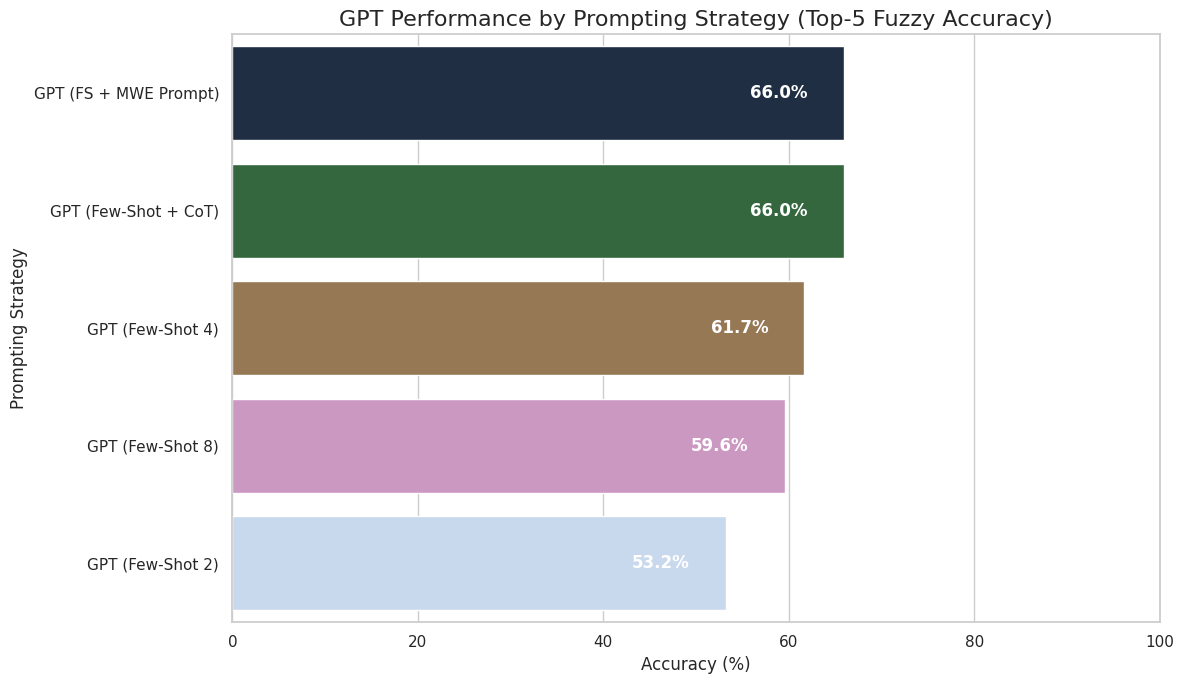

Graph saved as 'gpt_strategy_comparison.png'

Generating Graph 2: Impact of Few-Shot Examples...


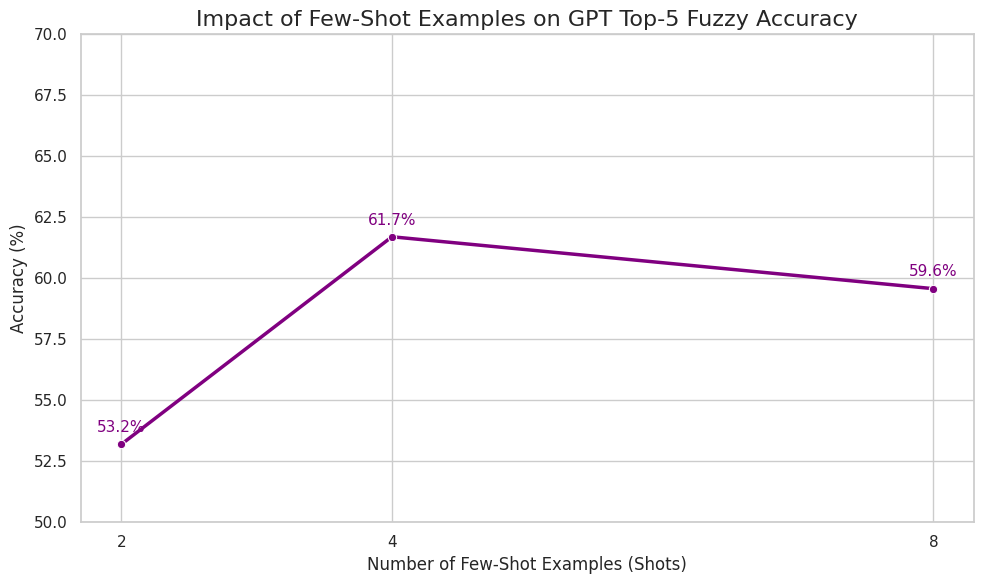

Graph saved as 'few_shot_impact.png'

Generating Graph 3: Advanced Prompting Techniques...


/tmp/ipython-input-1121174621.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_adv = sns.barplot(x='Technique', y='Accuracy (%)', data=df_advanced, palette='magma')


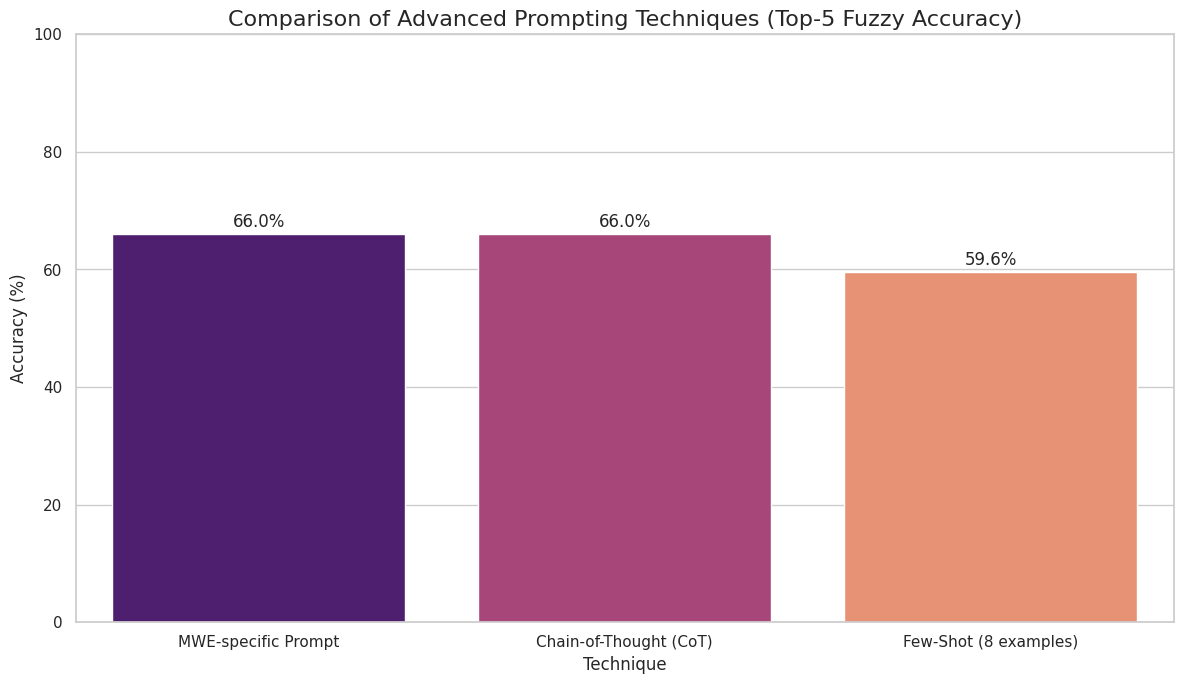

Graph saved as 'advanced_prompting_comparison.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('last_results_with_predictions.csv')

sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

## Graph 1: GPT Prompting Strategy Comparison
print("Generating Graph 1: GPT Prompting Strategy Comparison...")

accuracy_scores_gpt = {
    'GPT (FS + MWE Prompt)': df['gpt_correct_top5_mwe_fs_fuzzy'].mean() * 100,
    'GPT (Few-Shot 8)': df['gpt_correct_top5_few_shot_fuzzy_8'].mean() * 100,
    'GPT (Few-Shot + CoT)': df['mwe_few_shot_top5_cot_is_correct_fuzzy_top5'].mean() * 100,
    'GPT (Few-Shot 4)': df['gpt_correct_top5_few_shot_fuzzy_4'].mean() * 100,
    'GPT (Few-Shot 2)': df['gpt_correct_top5_few_shot_fuzzy_2'].mean() * 100
}

df_accuracy_gpt = pd.DataFrame(list(accuracy_scores_gpt.items()), columns=['Strategy', 'Accuracy (%)']).sort_values('Accuracy (%)', ascending=False)

plt.figure(figsize=(12, 7))
barplot_gpt = sns.barplot(x='Accuracy (%)', y='Strategy', data=df_accuracy_gpt, palette='cubehelix', orient='h')
plt.title('GPT Performance by Prompting Strategy (Top-5 Fuzzy Accuracy)', fontsize=16)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Prompting Strategy', fontsize=12)
plt.xlim(0, 100)

for p in barplot_gpt.patches:
    width = p.get_width()
    plt.text(width - 7, p.get_y() + p.get_height() / 2,
             f'{width:.1f}%',
             ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('gpt_strategy_comparison.png')
plt.show()
print("Graph saved as 'gpt_strategy_comparison.png'")

## Graph 2: Impact of Number of Few-Shot Examples
print("\nGenerating Graph 2: Impact of Few-Shot Examples...")

few_shot_data = {
    'Number of Examples': [2, 4, 8],
    'Accuracy (%)': [
        df['gpt_correct_top5_few_shot_fuzzy_2'].mean() * 100,
        df['gpt_correct_top5_few_shot_fuzzy_4'].mean() * 100,
        df['gpt_correct_top5_few_shot_fuzzy_8'].mean() * 100
    ]
}
df_few_shot = pd.DataFrame(few_shot_data)

plt.figure(figsize=(10, 6))
lineplot = sns.lineplot(x='Number of Examples', y='Accuracy (%)', data=df_few_shot, marker='o', color='purple', linewidth=2.5)
plt.title('Impact of Few-Shot Examples on GPT Top-5 Fuzzy Accuracy', fontsize=16)
plt.xlabel('Number of Few-Shot Examples (Shots)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks([2, 4, 8])
plt.ylim(50, 70)

for index, row in df_few_shot.iterrows():
    plt.text(row['Number of Examples'], row['Accuracy (%)'] + 0.5, f"{row['Accuracy (%)']:.1f}%",
             ha='center', color='purple', fontsize=11)

plt.tight_layout()
plt.savefig('few_shot_impact.png')
plt.show()
print("Graph saved as 'few_shot_impact.png'")


## Graph 3: Advanced Prompting Techniques Comparison
print("\nGenerating Graph 3: Advanced Prompting Techniques...")

advanced_prompt_data = {
    'Technique': ['Few-Shot (8 examples)', 'MWE-specific Prompt', 'Chain-of-Thought (CoT)'],
    'Accuracy (%)': [
        df['gpt_correct_top5_few_shot_fuzzy_8'].mean() * 100,
        df['gpt_correct_top5_mwe_fs_fuzzy'].mean() * 100,
        df['mwe_few_shot_top5_cot_is_correct_fuzzy_top5'].mean() * 100
    ]
}
df_advanced = pd.DataFrame(advanced_prompt_data).sort_values('Accuracy (%)', ascending=False)

plt.figure(figsize=(12, 7))
barplot_adv = sns.barplot(x='Technique', y='Accuracy (%)', data=df_advanced, palette='magma')
plt.title('Comparison of Advanced Prompting Techniques (Top-5 Fuzzy Accuracy)', fontsize=16)
plt.xlabel('Technique', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

for p in barplot_adv.patches:
   barplot_adv.annotate(f"{p.get_height():.1f}%",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center',
                  xytext = (0, 9),
                  textcoords = 'offset points')

plt.tight_layout()
plt.savefig('advanced_prompting_comparison.png')
plt.show()
print("Graph saved as 'advanced_prompting_comparison.png'")

--- Comprehensive Summary Table ---
                        Top-1 Exact (%)  Top-1 Fuzzy (%)  Top-5 Exact (%)  \
Strategy                                                                    
GPT (Few-Shot 2)                  27.66            36.17            46.81   
GPT (Few-Shot 4)                    NaN              NaN            55.32   
GPT (Few-Shot 8)                    NaN              NaN            51.06   
GPT (FS + MWE Prompt)               NaN              NaN            57.45   
GPT (Chain-of-Thought)            34.04            46.81            59.57   

                        Top-5 Fuzzy (%)  
Strategy                                 
GPT (Few-Shot 2)                  53.19  
GPT (Few-Shot 4)                  61.70  
GPT (Few-Shot 8)                  59.57  
GPT (FS + MWE Prompt)             65.96  
GPT (Chain-of-Thought)            65.96  

Graph (Heatmap) saved as 'comprehensive_heatmap.png'


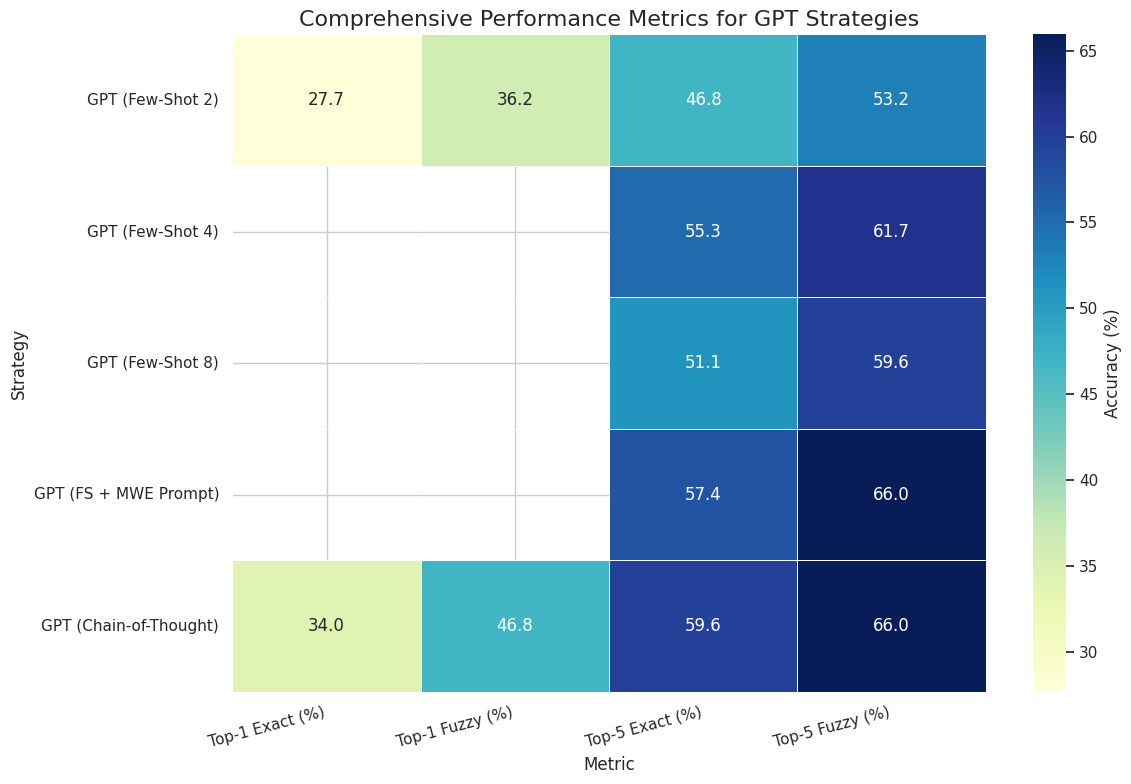

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('last_results_with_predictions.csv')

sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

summary_data = {
    'Strategy': [
        'GPT (Few-Shot 2)',
        'GPT (Few-Shot 4)',
        'GPT (Few-Shot 8)',
        'GPT (FS + MWE Prompt)',
        'GPT (Chain-of-Thought)'
    ],
    'Top-1 Exact (%)': [
        df['gpt_correct_few_shot_exact'].mean() * 100,
        np.nan,
        np.nan,
        np.nan,
        df['identify_and_complete_mwe_is_correct_exact'].mean() * 100
    ],
    'Top-1 Fuzzy (%)': [
        df['gpt_correct_few_shot_fuzzy'].mean() * 100,
        np.nan,
        np.nan,
        np.nan,
        df['identify_and_complete_mwe_is_correct_fuzzy'].mean() * 100
    ],
    'Top-5 Exact (%)': [
        df['gpt_correct_top5_few_shot_exact_2'].mean() * 100,
        df['gpt_correct_top5_few_shot_exact_4'].mean() * 100,
        df['gpt_correct_top5_few_shot_exact_8'].mean() * 100,
        df['gpt_correct_top5_mwe_fs_exact'].mean() * 100,
        df['mwe_few_shot_top5_cot_is_correct_exact_top5'].mean() * 100
    ],
    'Top-5 Fuzzy (%)': [
        df['gpt_correct_top5_few_shot_fuzzy_2'].mean() * 100,
        df['gpt_correct_top5_few_shot_fuzzy_4'].mean() * 100,
        df['gpt_correct_top5_few_shot_fuzzy_8'].mean() * 100,
        df['gpt_correct_top5_mwe_fs_fuzzy'].mean() * 100,
        df['mwe_few_shot_top5_cot_is_correct_fuzzy_top5'].mean() * 100
    ]
}

df_summary = pd.DataFrame(summary_data).set_index('Strategy')

print("--- Comprehensive Summary Table ---")
print(df_summary.round(2))

plt.figure(figsize=(12, 8))
sns.heatmap(df_summary, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Accuracy (%)'})
plt.title('Comprehensive Performance Metrics for GPT Strategies', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Strategy', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('comprehensive_heatmap.png')
print("\nGraph (Heatmap) saved as 'comprehensive_heatmap.png'")
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.5 MB/s eta 0:00:00


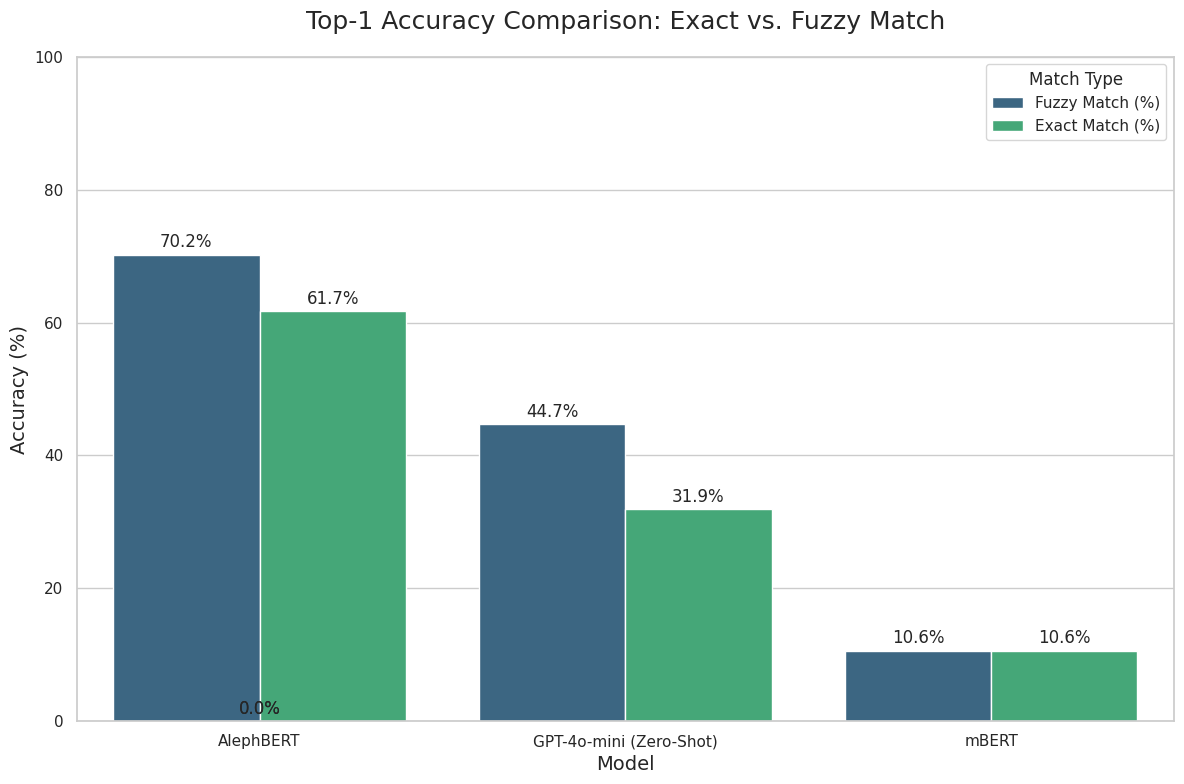

In [ ]:
!pip install thefuzz python-levenshtein

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from thefuzz import fuzz

df = pd.read_csv('mwe_predictions_all_models.csv')

def is_match_fuzzy(word1, word2, threshold=85):
    if not isinstance(word1, str) or not isinstance(word2, str):
        return False
    return fuzz.partial_ratio(str(word1).lower(), str(word2).lower()) >= threshold

df['alephbert_correct'] = df.apply(lambda row: str(row['masked_word']).lower() == str(row['alephbert_prediction']).lower(), axis=1)
df['mbert_correct'] = df.apply(lambda row: str(row['masked_word']).lower() == str(row['mbert_prediction']).lower(), axis=1)
df['gpt_correct'] = df.apply(lambda row: str(row['masked_word']).lower() == str(row['gpt_prediction']).lower(), axis=1)


df['alephbert_fuzzy_correct'] = df.apply(lambda row: is_match_fuzzy(row['masked_word'], row['alephbert_prediction']), axis=1)
df['mbert_fuzzy_correct'] = df.apply(lambda row: is_match_fuzzy(row['masked_word'], row['mbert_prediction']), axis=1)
df['gpt_fuzzy_correct'] = df.apply(lambda row: is_match_fuzzy(row['masked_word'], row['gpt_prediction']), axis=1)

summary_data = {
    'Model': ['AlephBERT', 'mBERT', 'GPT-4o-mini (Zero-Shot)'],
    'Exact Match (%)': [
        df['alephbert_correct'].mean() * 100,
        df['mbert_correct'].mean() * 100,
        df['gpt_correct'].mean() * 100
    ],
    'Fuzzy Match (%)': [
        df['alephbert_fuzzy_correct'].mean() * 100,
        df['mbert_fuzzy_correct'].mean() * 100,
        df['gpt_fuzzy_correct'].mean() * 100
    ]
}
df_summary = pd.DataFrame(summary_data)
df_melted = df_summary.melt(id_vars='Model', var_name='Match Type', value_name='Accuracy').sort_values('Accuracy', ascending=False)

plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Model', y='Accuracy', hue='Match Type', data=df_melted, palette='viridis')
plt.title('Top-1 Accuracy Comparison: Exact vs. Fuzzy Match', fontsize=18, pad=20)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(0, 100)

for p in barplot.patches:
   barplot.annotate(f"{p.get_height():.1f}%",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center',
                  xytext = (0, 9),
                  textcoords = 'offset points',
                  fontsize=12)

plt.tight_layout()
plt.savefig('final_summary_chart_with_fuzzy.png')
plt.show()

Graph saved as 'error_distribution_analysis.png'


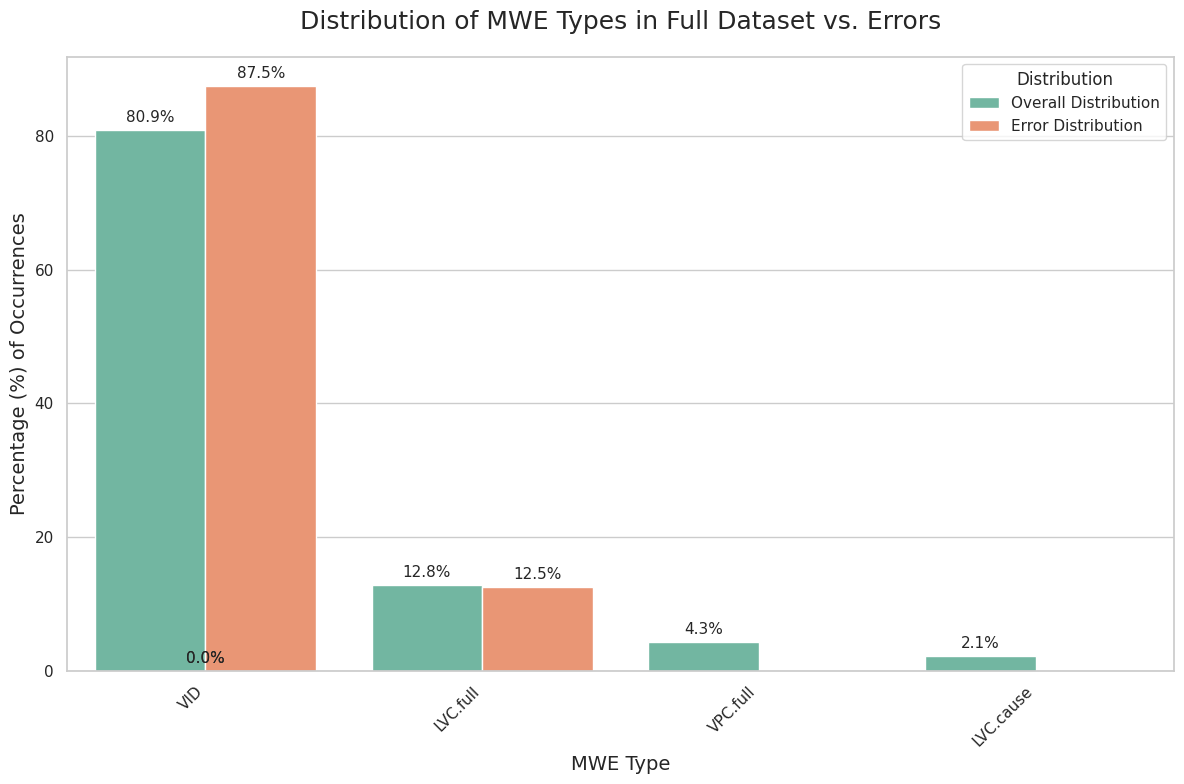

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('last_results_with_predictions.csv')

sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

hard_errors = df[df['gpt_correct_top5_mwe_fs_fuzzy'] == False].copy()

error_mwe_counts = hard_errors['type'].value_counts(normalize=True) * 100
error_dist = error_mwe_counts.reset_index()
error_dist.columns = ['MWE Type', 'Percentage']
error_dist['Distribution'] = 'Error Distribution'

total_mwe_counts = df['type'].value_counts(normalize=True) * 100
total_dist = total_mwe_counts.reset_index()
total_dist.columns = ['MWE Type', 'Percentage']
total_dist['Distribution'] = 'Overall Distribution'

combined_dist = pd.concat([total_dist, error_dist])

plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='MWE Type', y='Percentage', hue='Distribution', data=combined_dist, palette='Set2')

plt.title('Distribution of MWE Types in Full Dataset vs. Errors', fontsize=18, pad=20)
plt.xlabel('MWE Type', fontsize=14)
plt.ylabel('Percentage (%) of Occurrences', fontsize=14)
plt.xticks(rotation=45, ha='right')

for p in barplot.patches:
   barplot.annotate(f"{p.get_height():.1f}%",
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha = 'center', va = 'center',
                  xytext = (0, 9),
                  textcoords = 'offset points',
                  fontsize=11)

plt.tight_layout()
plt.savefig('error_distribution_analysis.png')
print("Graph saved as 'error_distribution_analysis.png'")
plt.show()